# Proyecto 1 - Data Mining UTEC
## Procesamiento y Analisis de Datos Masivos sobre MovieLens 20M

Notebook autocontenido para **Databricks** (cluster con PySpark + Photon). Cubre las 5 partes del proyecto sobre el dataset MovieLens 20M (20,000,263 ratings, 138,493 usuarios, 26,744 peliculas).

### Mapa de ejecucion (Spark distribuido vs Local)

| Parte | Tarea | Donde corre | Por que |
|---|---|---|---|
| I.1 | Preprocesamiento (nulls, duplicados, generos, binarizacion) | **Spark** | El dataset (~500 MB) excede la memoria de un nodo y se lee particionado. |
| I.2 | EDA (conteos, percentiles, sparsity, generos) | **Spark + Local** | Spark agrega; los resultados (decenas de filas) se traen a pandas para graficar. |
| II | Conteos, ranking top-20, benchmark RDD vs DataFrame | **Spark** | Operaciones nativamente distribuidas; el benchmark mide overhead de cada API. |
| III.1-3.2 | Construccion `peliculas_users`, muestra estratificada | **Spark** | Filtros y `groupBy` sobre 12M de likes. |
| III.3 | Jaccard exacto sobre 507K pares | **Spark** | `array_intersect` corre en JVM/Tungsten sin penalizacion Python. |
| III.4 | MinHash (firmas y barrido de K) | **Spark** | UDF con broadcast de hashes; el join `pares x firmas` se distribuye. |
| III.5 | LSH manual con barrido de (b, r) | **Spark** | Self-join de buckets sobre las firmas; barrido de 5 configuraciones. |
| IV.1-4.3 | FP-Growth (itemsets + reglas) | **Spark** (MLlib) | Implementacion distribuida nativa que escala a millones de transacciones. |
| IV.4-4.7 | Traduccion de IDs y ranking top-N de reglas | **Local (pandas)** | 2.2M reglas caben en RAM y el formateo es mas rapido en pandas. |
| Visualizaciones (todas las partes) | Render | **Local** (matplotlib/seaborn) | Solo el driver tiene acceso al display; agregamos en Spark, ploteamos en local. |
| V | Discusion y reflexion | Markdown | No hay calculo. |

### Estructura

| Parte | Contenido |
|---|---|
| I | Preprocesamiento y EDA |
| II | Procesamiento distribuido (RDD vs DataFrame) |
| III | Similitud, MinHashing y LSH (manual sobre Opcion A) |
| IV | Reglas de asociacion con FP-Growth |
| V | Discusion: trade-offs, escalabilidad, aplicabilidad real |

In [0]:
# ============================================================================
# CONFIGURACION GLOBAL Y CARGA DE DATOS
# ============================================================================
# En Databricks la SparkSession ya existe (variable `spark`). Si por alguna
# razon no estuviera, getOrCreate la crea con la configuracion del cluster.
# No fijamos memoria del driver/executor aqui: eso se controla en el cluster.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import (
    col, when, count, countDistinct, avg, round as spark_round,
    split, explode, regexp_extract, regexp_replace, trim,
    from_unixtime, to_date, year,
)

spark = SparkSession.builder.appName("MovieLens_20M_Proyecto1").getOrCreate()
print(f"Spark version: {spark.version}")
print(f"Aplicacion: {spark.sparkContext.appName}")

# Ruta del dataset en Databricks Volumes (ajustar al volumen del workspace en el que se trabaje).
BASE_PATH = "/Volumes/francisco/default/datasets/ml-20m"

ratings_df = spark.read.csv(f"{BASE_PATH}/ratings.csv", header=True, inferSchema=True)
movies_df = spark.read.csv(f"{BASE_PATH}/movies.csv", header=True, inferSchema=True)

print(f"Ratings cargados: {ratings_df.count():,}")
print(f"Movies cargadas:  {movies_df.count():,}")

Spark version: 4.1.0
Aplicacion: Databricks Shell
Ratings cargados: 20,000,263
Movies cargadas:  27,278


# PARTE I - Preprocesamiento y EDA

> **Ejecucion:** Spark distribuido para todas las agregaciones (DataFrame API). Los resultados ya reducidos (decenas de filas) se traen a pandas con `.toPandas()` solo para graficar con matplotlib/seaborn, porque las librerias de visualizacion son single-process.

> **Por que Spark aqui:** el archivo `ratings.csv` (~500 MB) supera la RAM tipica de un nodo y la lectura en pandas seria O(N) sobre un solo core; Spark lo particiona y procesa en paralelo desde el primer `read.csv`.

## 1.1 Preprocesamiento

### Limpieza de nulos y duplicados

El dataset oficial de MovieLens 20M esta bien curado: tras `dropna().dropDuplicates()` el conteo de filas no cambia (**20,000,263** ratings y **27,278** peliculas). El paso queda como chequeo defensivo: si en una iteracion futura el origen se reemplaza por un dump sucio, esta linea evita propagar nulls al resto del pipeline.

In [0]:
ratings_df = ratings_df.dropna().dropDuplicates()
movies_df = movies_df.dropna().dropDuplicates()
print(f"Ratings tras limpieza: {ratings_df.count():,}")
print(f"Movies  tras limpieza: {movies_df.count():,}")

Ratings tras limpieza: 20,000,263
Movies  tras limpieza: 27,278


### Unificacion de generos y normalizacion de titulos

El catalogo trae **20 generos distintos**. Tres requieren normalizacion:

- `Sci-Fi` → `Science Fiction` (forma canonica completa).
- `Film-Noir` → `Film Noir` (sin guion, consistente con el resto).
- `(no genres listed)` → `Unspecified` (etiqueta semanticamente clara para el 0.5% de peliculas sin genero asignado).

Adicionalmente:

- Extraemos **`year`** desde el titulo (`"Toy Story (1995)"` → `1995`).
- Reformateamos articulos: `"Matrix, The"` → `"The Matrix"` para que las visualizaciones queden en orden natural.
- Convertimos `timestamp` Unix a tipo `date` para analisis temporales.

In [0]:
# Lista los generos unicos para detectar inconsistencias.
generos_unicos = (
    movies_df
    .withColumn("genre_single", explode(split(col("genres"), "\\|")))
    .select("genre_single").distinct().orderBy("genre_single")
)
generos_unicos.show(40, truncate=False)

+------------------+
|genre_single      |
+------------------+
|(no genres listed)|
|Action            |
|Adventure         |
|Animation         |
|Children          |
|Comedy            |
|Crime             |
|Documentary       |
|Drama             |
|Fantasy           |
|Film-Noir         |
|Horror            |
|IMAX              |
|Musical           |
|Mystery           |
|Romance           |
|Sci-Fi            |
|Thriller          |
|War               |
|Western           |
+------------------+



In [0]:
# Extraemos year del titulo y normalizamos generos heterogeneos.
movies_df = (
    movies_df
    .withColumn("year", regexp_extract(col("title"), r"\((\d{4})\)", 1).cast("int"))
    .withColumn("title", trim(regexp_replace(col("title"), r"\(\d{4}\)", "")))
    .withColumn("title", regexp_replace(col("title"), r"(.+), (The|A|An)$", r"$2 $1"))
    .withColumn("genres", regexp_replace(col("genres"), "Sci-Fi", "Science Fiction"))
    .withColumn("genres", regexp_replace(col("genres"), r"\(no genres listed\)", "Unspecified"))
    .withColumn("genres", regexp_replace(col("genres"), "Film-Noir", "Film Noir"))
)

ratings_df = (
    ratings_df
    .withColumn("timestamp_dt", from_unixtime(col("timestamp")))
    .withColumn("date", to_date(col("timestamp_dt")))
)

movies_df.select("title", "year", "genres").show(5, truncate=False)

+---------------------------------+----+-------------------------+
|title                            |year|genres                   |
+---------------------------------+----+-------------------------+
|Headless Body in Topless Bar     |1995|Comedy|Drama|Thriller    |
|When a Man Loves a Woman         |1994|Drama|Romance            |
|Coup de torchon (Clean Slate)    |1981|Crime                    |
|Wallace & Gromit: A Close Shave  |1995|Animation|Children|Comedy|
|Tin Drum, The (Blechtrommel, Die)|1979|Drama|War                |
+---------------------------------+----+-------------------------+
only showing top 5 rows


### Binarizacion like / dislike

Usamos **umbral 3.5** porque MovieLens permite calificaciones en pasos de 0.5: un rating >= 3.5 representa una valoracion claramente positiva (por encima del 3.0 'aceptable') y produce un balance like/dislike mas informativo que un umbral en 3.0.

**Resultado del corte:** **61.0% likes** (12,195,566 ratings) vs **39.0% dislikes** (7,804,697 ratings). El balance es positivo pero no degenerado: ambas clases tienen masa suficiente para los analisis posteriores.

In [0]:
UMBRAL_LIKE = 3.5
ratings_df = ratings_df.withColumn(
    "like", when(col("rating") >= UMBRAL_LIKE, 1).otherwise(0)
)

ratings_df.groupBy("like").count().orderBy("like").show()

+----+--------+
|like|   count|
+----+--------+
|   0| 7804697|
|   1|12195566|
+----+--------+



## 1.2 Exploracion de datos (EDA)

Cada hallazgo va acompanado de su grafico. Donde tiene sentido comparar
poblaciones de tamano distinto se usan **graficos relativos (porcentajes)**.

### Distribucion de calificaciones

Histograma de las 10 categorias posibles (0.5 a 5.0 estrellas), expresado en **% del total** para lectura inmediata. Al lado, el resultado de la binarizacion como sanity check del umbral elegido.

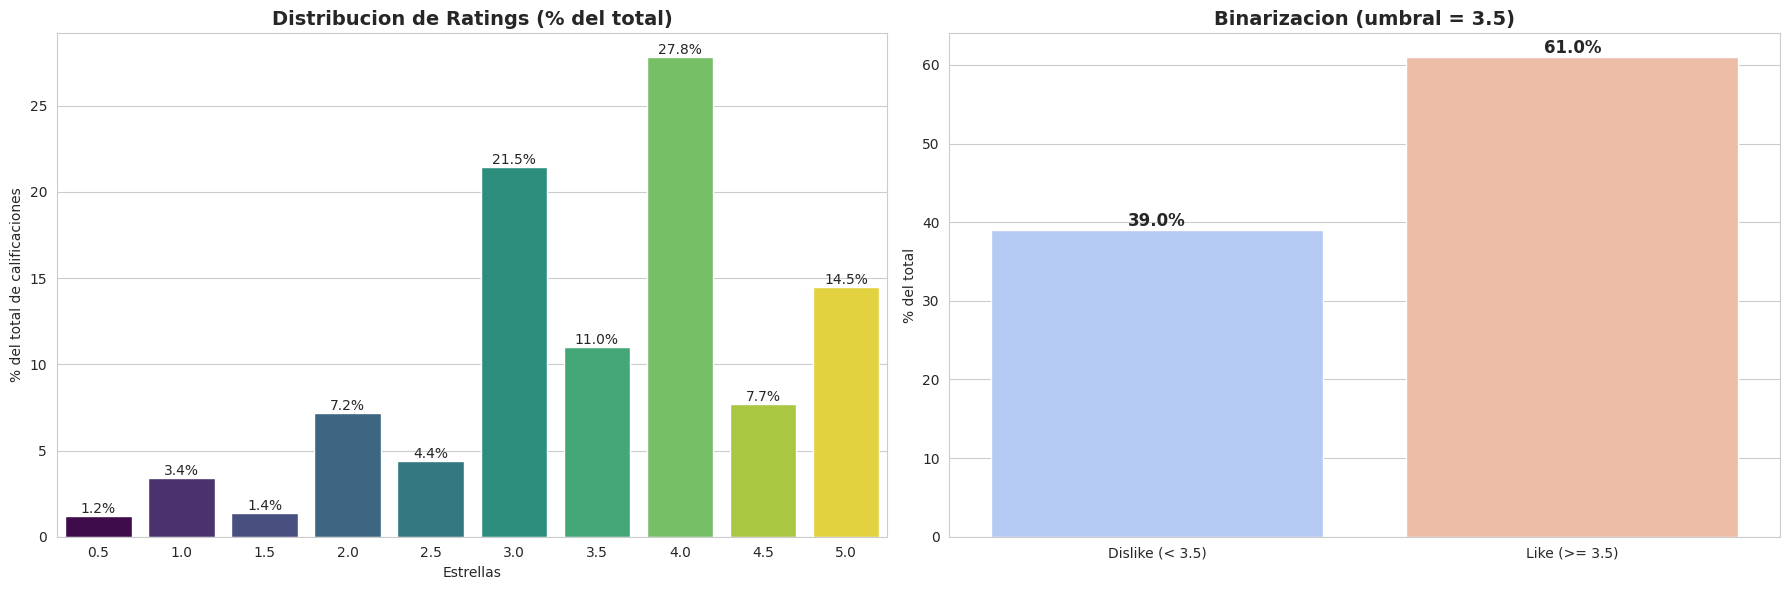

In [0]:
# Distribucion original + binarizacion (% sobre el total para comparar).
rating_dist_pd = ratings_df.groupBy("rating").count().orderBy("rating").toPandas()
binary_dist_pd = ratings_df.groupBy("like").count().orderBy("like").toPandas()
binary_dist_pd["label"] = binary_dist_pd["like"].map({1: "Like (>= 3.5)", 0: "Dislike (< 3.5)"})

total_ratings = rating_dist_pd["count"].sum()
rating_dist_pd["pct"] = 100 * rating_dist_pd["count"] / total_ratings
binary_dist_pd["pct"] = 100 * binary_dist_pd["count"] / total_ratings

sns.set_style("whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(x="rating", y="pct", data=rating_dist_pd, hue="rating",
            palette="viridis", ax=ax1, legend=False)
ax1.set_title("Distribucion de Ratings (% del total)", fontsize=14, fontweight="bold")
ax1.set_xlabel("Estrellas"); ax1.set_ylabel("% del total de calificaciones")
for p in ax1.patches:
    ax1.annotate(f"{p.get_height():.1f}%",
                 (p.get_x() + p.get_width() / 2, p.get_height()),
                 ha="center", va="bottom", fontsize=10)

sns.barplot(x="label", y="pct", data=binary_dist_pd, hue="label",
            palette="coolwarm", ax=ax2, legend=False)
ax2.set_title(f"Binarizacion (umbral = {UMBRAL_LIKE})",
              fontsize=14, fontweight="bold")
ax2.set_xlabel(""); ax2.set_ylabel("% del total")
for p in ax2.patches:
    ax2.annotate(f"{p.get_height():.1f}%",
                 (p.get_x() + p.get_width() / 2, p.get_height()),
                 ha="center", va="bottom", fontsize=12, fontweight="bold")

plt.tight_layout(); plt.show()

**Hallazgos:**

- La distribucion esta **fuertemente sesgada al alza**: el rating mas frecuente es `4.0` (**27.8%**), seguido de `3.0` (21.5%) y `5.0` (14.5%). Es coherente con el sesgo de auto-seleccion: los usuarios califican peliculas que decidieron ver, y rara vez puntuan algo que les disgusto.
- Los **ratings enteros dominan** sobre los medios-puntos (`3.0` = 21.5% vs `3.5` = 11.0%; `4.0` = 27.8% vs `4.5` = 7.7%). MovieLens introdujo los medios estrellas en 2003, parte de los ratings antiguos solo tenia opciones enteras y el habito persiste.
- El **umbral de 3.5** divide el dataset en **61% likes / 39% dislikes**, un balance suficientemente parejo para ambas clases sin caer en el degenerado donde una clase domina por completo.

### Calificaciones por usuario

Mostramos el top-10 de power users junto con una **curva de Pareto** que cuantifica la concentracion: que % de usuarios concentra que % del total de ratings.

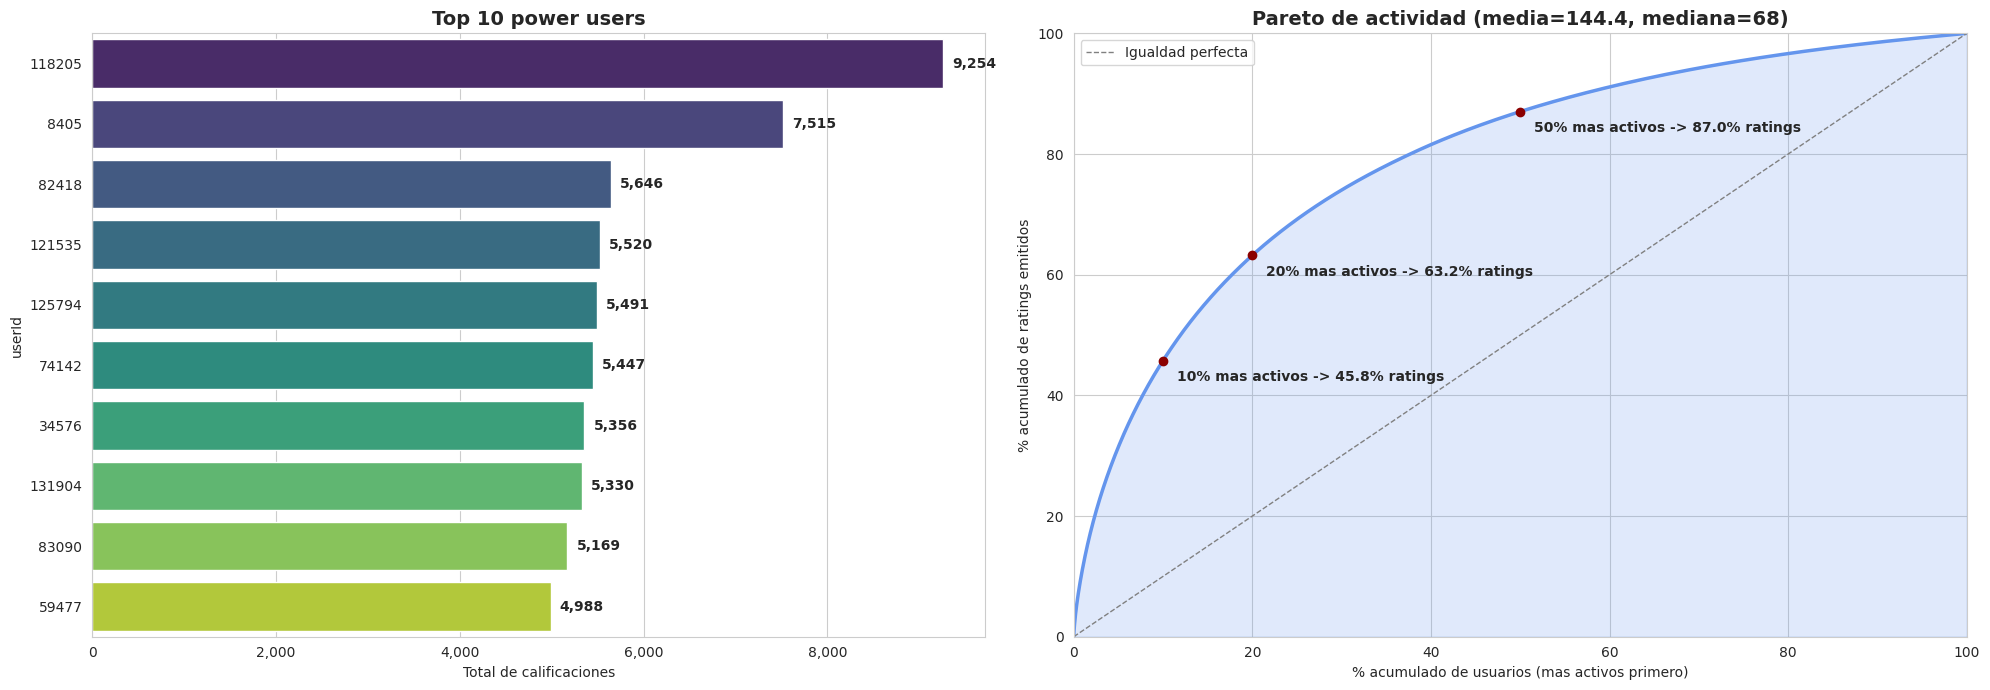

In [0]:
user_activity = ratings_df.groupBy("userId").agg(count("rating").alias("n_ratings"))
top_10_users = user_activity.orderBy(col("n_ratings").desc()).limit(10).toPandas()
user_activity_pd = user_activity.toPandas().sort_values("n_ratings", ascending=False)

# --- Pareto: % acumulado de usuarios vs % acumulado de ratings ---
n_users = len(user_activity_pd)
total_n = user_activity_pd["n_ratings"].sum()
user_activity_pd["cum_users_pct"] = 100 * (np.arange(n_users) + 1) / n_users
user_activity_pd["cum_ratings_pct"] = 100 * user_activity_pd["n_ratings"].cumsum() / total_n

media_val = user_activity_pd["n_ratings"].mean()
mediana_val = user_activity_pd["n_ratings"].median()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))
sns.set_style("whitegrid")

# Top 10 power users
sns.barplot(x="n_ratings", y=top_10_users["userId"].astype(str),
            data=top_10_users, hue=top_10_users["userId"].astype(str),
            palette="viridis", ax=ax1, legend=False)
ax1.set_title("Top 10 power users", fontsize=14, fontweight="bold")
ax1.set_xlabel("Total de calificaciones"); ax1.set_ylabel("userId")
for i, v in enumerate(top_10_users["n_ratings"]):
    ax1.text(v + 100, i, f"{v:,}", va="center", fontweight="bold")
ax1.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

# Pareto
ax2.plot(user_activity_pd["cum_users_pct"],
         user_activity_pd["cum_ratings_pct"],
         color="cornflowerblue", linewidth=2.5)
ax2.fill_between(user_activity_pd["cum_users_pct"],
                 user_activity_pd["cum_ratings_pct"],
                 alpha=0.2, color="cornflowerblue")
ax2.plot([0, 100], [0, 100], "--", color="gray", linewidth=1, label="Igualdad perfecta")
for x in [10, 20, 50]:
    y = np.interp(x, user_activity_pd["cum_users_pct"], user_activity_pd["cum_ratings_pct"])
    ax2.scatter([x], [y], color="darkred", zorder=5)
    ax2.annotate(f"{x}% mas activos -> {y:.1f}% ratings",
                 (x, y), xytext=(10, -15), textcoords="offset points",
                 fontsize=10, fontweight="bold")
ax2.set_title(f"Pareto de actividad (media={media_val:.1f}, mediana={mediana_val:.0f})",
              fontsize=14, fontweight="bold")
ax2.set_xlabel("% acumulado de usuarios (mas activos primero)")
ax2.set_ylabel("% acumulado de ratings emitidos")
ax2.set_xlim(0, 100); ax2.set_ylim(0, 100); ax2.legend()
plt.tight_layout(); plt.show()

**Hallazgos:**

- **Distribucion fuertemente desbalanceada**: media = **144.4** ratings/usuario, mediana = **68**. La media es mas del doble que la mediana, signo clasico de heavy-tail.
- El **power user mas activo** (userId 118205) ha calificado **9,254 peliculas** - mas del 4% del catalogo total.
- **Curva de Pareto** muestra concentracion fuerte:
  - El **10% mas activo** genera el **45.8%** de los ratings.
  - El **20% mas activo** genera el **63.2%**.
  - El **50% mas activo** genera el **87.0%**.
- **Implicacion para Parte III:** filtrar a usuarios con `>= 20 likes` retiene cerca del 77% de los usuarios y el 95% del volumen de likes - la cola larga aporta poca informacion para Jaccard pero engrosa los conjuntos.

### Calificaciones por pelicula

Tres vistas complementarias: top-10 mas calificadas, distribucion completa de popularidad (escala log) con media y mediana marcadas, y top-10 menos calificadas como contrapunto.

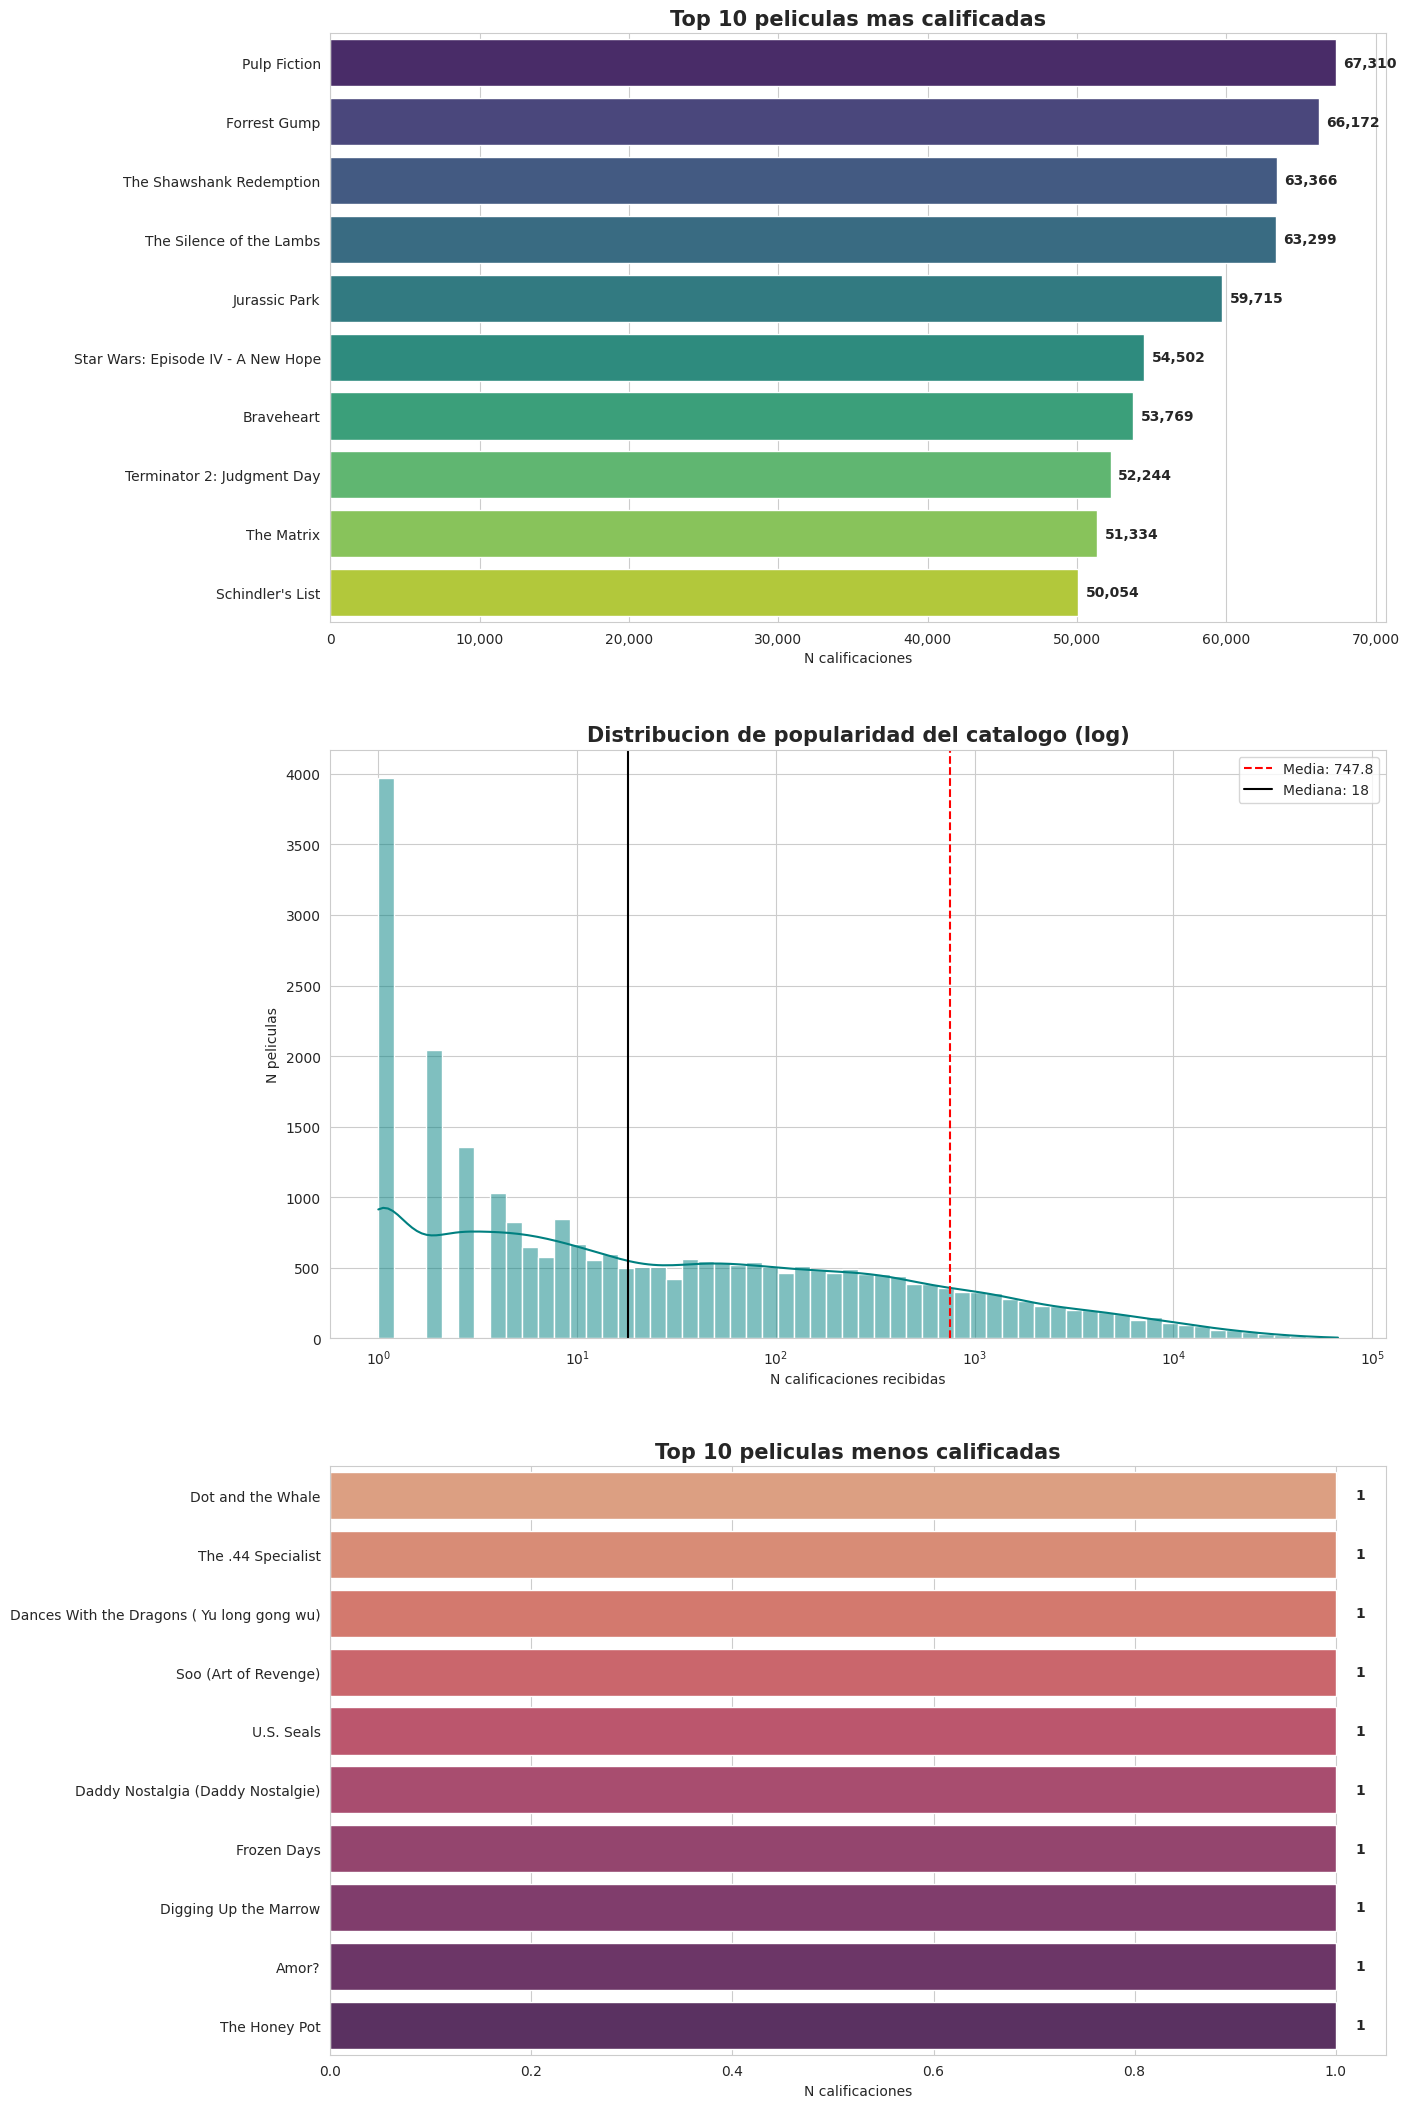

In [0]:
movie_counts = ratings_df.groupBy("movieId").agg(count("rating").alias("n_ratings"))
movie_counts_named = movie_counts.join(movies_df.select("movieId", "title"), "movieId")
top_10_pop = movie_counts_named.orderBy(col("n_ratings").desc()).limit(10).toPandas()
bottom_10_pop = movie_counts_named.orderBy(col("n_ratings").asc()).limit(10).toPandas()
movie_activity_pd = movie_counts.select("n_ratings").toPandas()

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 22))
sns.set_style("whitegrid")

sns.barplot(x="n_ratings", y="title", data=top_10_pop, hue="title",
            palette="viridis", ax=ax1, legend=False)
ax1.set_title("Top 10 peliculas mas calificadas", fontsize=15, fontweight="bold")
ax1.set_xlabel("N calificaciones"); ax1.set_ylabel("")
for i, v in enumerate(top_10_pop["n_ratings"]):
    ax1.text(v + 500, i, f"{v:,}", va="center", fontweight="bold")
ax1.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

sns.histplot(movie_activity_pd["n_ratings"], bins=60, kde=True, color="teal",
             ax=ax2, log_scale=True)
media_m = movie_activity_pd["n_ratings"].mean()
mediana_m = movie_activity_pd["n_ratings"].median()
ax2.axvline(media_m, color="red", linestyle="--", label=f"Media: {media_m:.1f}")
ax2.axvline(mediana_m, color="black", linestyle="-", label=f"Mediana: {mediana_m:.0f}")
ax2.set_title("Distribucion de popularidad del catalogo (log)",
              fontsize=15, fontweight="bold")
ax2.set_xlabel("N calificaciones recibidas"); ax2.set_ylabel("N peliculas")
ax2.legend()

sns.barplot(x="n_ratings", y="title", data=bottom_10_pop, hue="title",
            palette="flare", ax=ax3, legend=False)
ax3.set_title("Top 10 peliculas menos calificadas", fontsize=15, fontweight="bold")
ax3.set_xlabel("N calificaciones"); ax3.set_ylabel("")
for i, v in enumerate(bottom_10_pop["n_ratings"]):
    ax3.text(v + 0.02, i, f"{v:,}", va="center", fontweight="bold")

plt.tight_layout(pad=4.0); plt.show()

**Hallazgos:**

- El **top-10 esta dominado por blockbusters de los 90s**: Pulp Fiction (67,310), Forrest Gump (66,172), The Shawshank Redemption (63,366), The Silence of the Lambs (63,299), Jurassic Park (59,715). Son los icones que cualquier usuario activo de MovieLens habra puntuado.
- La distribucion es **mas asimetrica que la de usuarios**: media = **747.8**, mediana = **18**. La media es ~40x la mediana - el heavy-tail es brutal.
- En el **bottom-10 cada pelicula tiene exactamente 1 rating** (Dot and the Whale, The .44 Specialist, etc.). Hay miles de peliculas con conteos minusculos.
- **Implicacion para Parte III:** filtrar peliculas con `>= 50 likes` deja solo ~36% del catalogo (8,362 peliculas) pero estas concentran la masa de evidencia que necesita Jaccard para ser estadisticamente robusto.

### Distribucion de generos: catalogo vs calificaciones (grafico relativo)

Comparar conteos absolutos de peliculas y de ratings por genero es enganoso
porque los totales son de ordenes de magnitud distintos. Usamos un **grafico
relativo (% de cada genero dentro de su poblacion)** para detectar generos
sobre-representados (mas % de ratings que % de catalogo) y sub-representados.

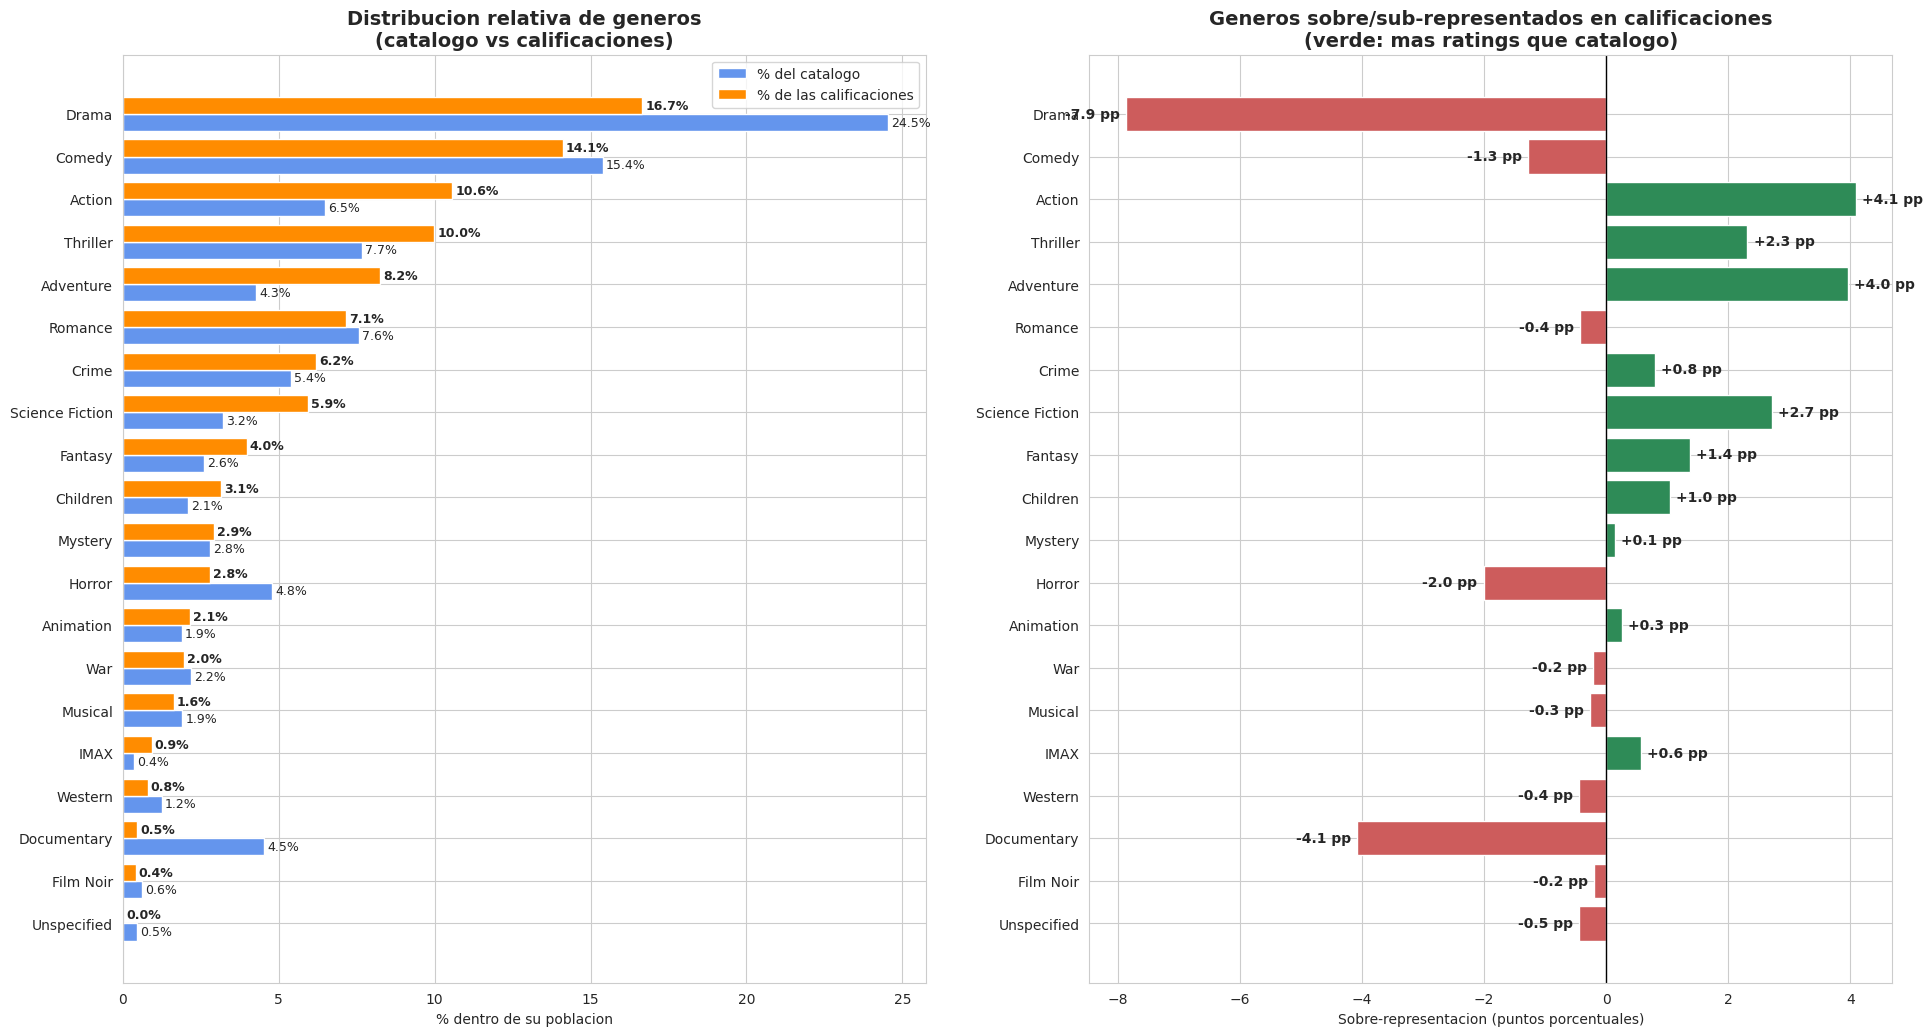

In [0]:
movies_genres = movies_df.withColumn("genre", explode(split(col("genres"), "\\|")))
cat_dist = movies_genres.groupBy("genre").count().toPandas()
cat_dist["pct_catalogo"] = 100 * cat_dist["count"] / cat_dist["count"].sum()
cat_dist = cat_dist.rename(columns={"count": "n_peliculas"})

ratings_genres = (
    ratings_df.join(movies_df, "movieId")
    .withColumn("genre", explode(split(col("genres"), "\\|")))
)
rat_dist = ratings_genres.groupBy("genre").count().toPandas()
rat_dist["pct_ratings"] = 100 * rat_dist["count"] / rat_dist["count"].sum()
rat_dist = rat_dist.rename(columns={"count": "n_ratings"})

# Merge para grafico comparativo
gen_cmp = (
    cat_dist[["genre", "pct_catalogo"]]
    .merge(rat_dist[["genre", "pct_ratings"]], on="genre")
    .sort_values("pct_ratings", ascending=True)
)
gen_cmp["delta"] = gen_cmp["pct_ratings"] - gen_cmp["pct_catalogo"]

fig, axes = plt.subplots(1, 2, figsize=(20, 11))
sns.set_style("whitegrid")

# (a) % en catalogo vs % en ratings, lado a lado
ax = axes[0]
y = np.arange(len(gen_cmp))
ax.barh(y - 0.2, gen_cmp["pct_catalogo"], height=0.4,
        color="cornflowerblue", label="% del catalogo")
ax.barh(y + 0.2, gen_cmp["pct_ratings"], height=0.4,
        color="darkorange", label="% de las calificaciones")
ax.set_yticks(y); ax.set_yticklabels(gen_cmp["genre"])
ax.set_xlabel("% dentro de su poblacion")
ax.set_title("Distribucion relativa de generos\n(catalogo vs calificaciones)",
             fontsize=14, fontweight="bold")
ax.legend()
for i, (pc, pr) in enumerate(zip(gen_cmp["pct_catalogo"], gen_cmp["pct_ratings"])):
    ax.text(pc + 0.1, i - 0.2, f"{pc:.1f}%", va="center", fontsize=9)
    ax.text(pr + 0.1, i + 0.2, f"{pr:.1f}%", va="center", fontsize=9, fontweight="bold")

# (b) Delta = % ratings - % catalogo (sobre/sub representacion)
ax = axes[1]
colors = ["seagreen" if d >= 0 else "indianred" for d in gen_cmp["delta"]]
ax.barh(gen_cmp["genre"], gen_cmp["delta"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Sobre-representacion (puntos porcentuales)")
ax.set_title("Generos sobre/sub-representados en calificaciones\n(verde: mas ratings que catalogo)",
             fontsize=14, fontweight="bold")
for i, d in enumerate(gen_cmp["delta"]):
    ax.text(d + (0.1 if d >= 0 else -0.1), i, f"{d:+.1f} pp",
            va="center", ha="left" if d >= 0 else "right", fontsize=10, fontweight="bold")

plt.tight_layout(pad=3.0); plt.show()

**Lectura del grafico relativo:**

**Generos sobre-representados** (mas % de ratings que % de catalogo):

- **Action** (+4.1 pp): 6.5% del catalogo -> **10.6%** de los ratings.
- **Adventure** (+4.0 pp): 4.3% -> 8.2%.
- **Science Fiction** (+2.7 pp), **Thriller** (+2.3 pp), **Fantasy** (+1.4 pp), **Children** (+1.0 pp).

Son generos comerciales / familiares: una pelicula popular acumula muchas calificaciones porque tiene muchos espectadores.

**Generos sub-representados** (mas catalogo que ratings):

- **Drama** (-7.9 pp): pesa **24.5%** del catalogo pero solo **16.7%** de las calificaciones. Hay muchos dramas de nicho que pocos usuarios ven.
- **Documentary** (-4.1 pp): 4.5% catalogo -> 0.5% ratings. La asimetria mas dramatica del catalogo.
- **Horror** (-2.0 pp), **Comedy** (-1.3 pp).

**Implicacion para el modelado:** dado que el genero por si solo no explica bien las preferencias (un drama tiene -7.9 pp respecto al peso esperable), una representacion basada en **co-preferencia de usuarios (Opcion A)** es mas informativa que una basada en metadatos de genero. Esto justifica la decision tomada en la Parte III.

### Densidad / sparsity de la matriz usuario-pelicula

La matriz `userId x movieId` tiene `138,493 x 26,744 ≈ 3.7 mil millones` de celdas posibles, pero solo 20M tienen rating. Visualizamos la **densidad real** (pie chart) y el **patron espacial** sobre una submuestra densa (top-500 usuarios x top-500 peliculas) para ver si la sparsity es uniforme o estructurada.

ANALISIS DE DENSIDAD Y SPARSITY
Usuarios unicos:        138,493
Peliculas unicas:       26,744
Ratings reales:         20,000,263
Interacciones posibles: 3,703,856,792
DENSIDAD: 0.5400%
SPARSITY: 99.4600%


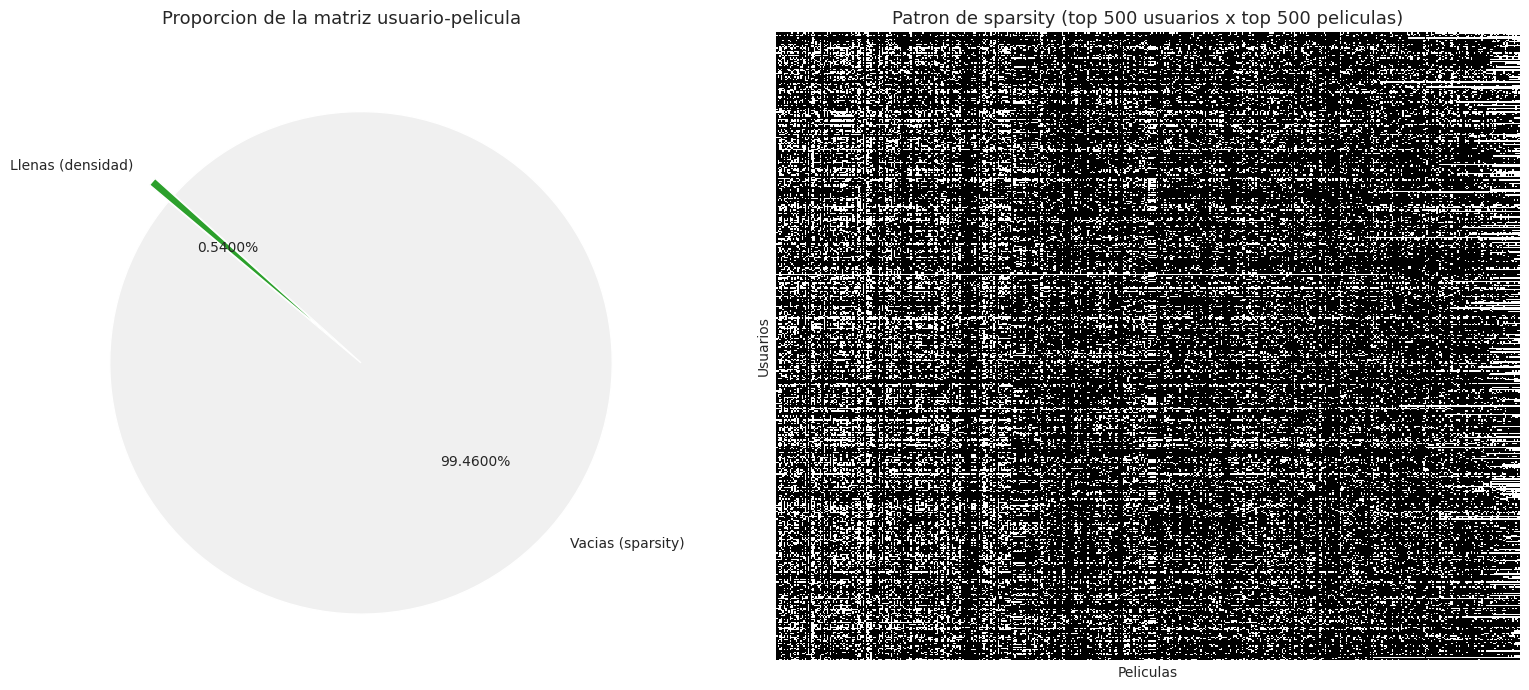

In [0]:
print("ANALISIS DE DENSIDAD Y SPARSITY")

num_ratings = ratings_df.count()
num_users = ratings_df.select("userId").distinct().count()
num_movies = ratings_df.select("movieId").distinct().count()

interacciones_posibles = num_users * num_movies
densidad = num_ratings / interacciones_posibles
sparsity = 1 - densidad

print(f"Usuarios unicos:        {num_users:,}")
print(f"Peliculas unicas:       {num_movies:,}")
print(f"Ratings reales:         {num_ratings:,}")
print(f"Interacciones posibles: {interacciones_posibles:,}")
print(f"DENSIDAD: {densidad * 100:.4f}%")
print(f"SPARSITY: {sparsity * 100:.4f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
ax1.pie([sparsity, densidad], labels=["Vacias (sparsity)", "Llenas (densidad)"],
        colors=["#f0f0f0", "#2ca02c"], explode=(0.1, 0),
        autopct="%1.4f%%", startangle=140)
ax1.set_title("Proporcion de la matriz usuario-pelicula", fontsize=13)

# Heatmap de patron de sparsity sobre top-500 x top-500
top_users = (ratings_df.groupBy("userId").count()
             .orderBy(F.desc("count")).limit(500).select("userId"))
top_movies = (ratings_df.groupBy("movieId").count()
              .orderBy(F.desc("count")).limit(500).select("movieId"))
muestra_densa = ratings_df.join(top_users, "userId").join(top_movies, "movieId")
pdf_muestra = muestra_densa.select("userId", "movieId", "rating").toPandas()
matriz_visual = pdf_muestra.pivot(index="userId", columns="movieId", values="rating")
sns.heatmap(matriz_visual.notna(), cmap="Greys", cbar=False,
            xticklabels=False, yticklabels=False, ax=ax2)
ax2.set_title("Patron de sparsity (top 500 usuarios x top 500 peliculas)",
              fontsize=13)
ax2.set_xlabel("Peliculas"); ax2.set_ylabel("Usuarios")
plt.tight_layout(); plt.show()

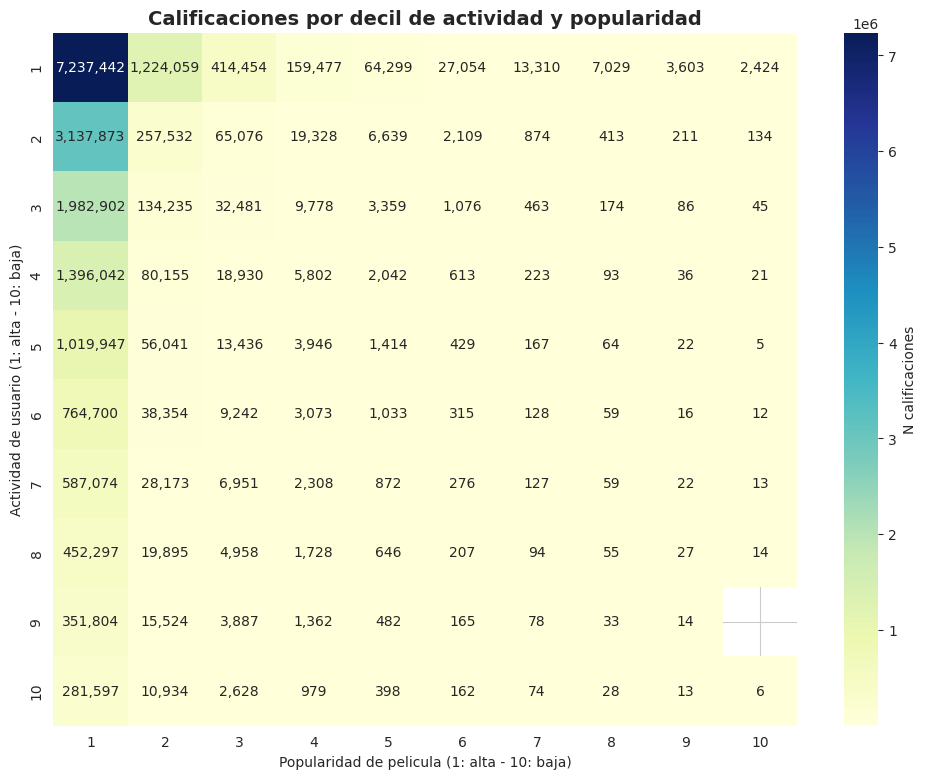

In [0]:
# Heatmap de actividad/popularidad por deciles (lectura mas analitica que
# el patron visual: cuantos ratings ocurren entre cada combinacion de
# 'usuario activo' x 'pelicula popular').
from pyspark.sql.window import Window
from pyspark.sql.functions import ntile

user_activity = ratings_df.groupBy("userId").agg(count("rating").alias("u_act"))
movie_pop = ratings_df.groupBy("movieId").agg(count("rating").alias("m_pop"))

user_ranks = user_activity.withColumn(
    "Rango_Usuario", ntile(10).over(Window.orderBy(col("u_act").desc()))
)
movie_ranks = movie_pop.withColumn(
    "Rango_Pelicula", ntile(10).over(Window.orderBy(col("m_pop").desc()))
)

binned = (
    ratings_df.join(user_ranks, "userId").join(movie_ranks, "movieId")
    .groupBy("Rango_Usuario", "Rango_Pelicula").count().toPandas()
)
matrix_final = binned.pivot(index="Rango_Usuario", columns="Rango_Pelicula", values="count")

plt.figure(figsize=(12, 9))
sns.heatmap(matrix_final, annot=True, fmt=",.0f", cmap="YlGnBu", 
            cbar_kws={"label": "N calificaciones"})
plt.title("Calificaciones por decil de actividad y popularidad",
          fontsize=14, fontweight="bold")
plt.xlabel("Popularidad de pelicula (1: alta - 10: baja)")
plt.ylabel("Actividad de usuario (1: alta - 10: baja)")
plt.show()

**Hallazgos sobre densidad y patron de cobertura:**

- **Sparsity = 99.46%**: el 99.46% de las combinaciones usuario-pelicula nunca ocurrieron. Es lo esperable en sistemas de recomendacion reales (Netflix, Spotify, Amazon operan con sparsity > 99.9%).
- El **heatmap por deciles** revela una concentracion extrema en la esquina superior izquierda: el **top-10% de usuarios x top-10% de peliculas** concentra **7,237,442 ratings** (~36% del total).
- A medida que nos alejamos de los blockbusters/power-users la densidad cae **dos ordenes de magnitud**: el cruce decil-1 (mas activos) x decil-10 (peliculas mas oscuras) tiene 2,424 ratings; el cruce decil-10 x decil-10 tiene apenas 6 ratings.
- **Implicacion para LSH (Parte III):** el espacio donde "vive" la senal de similitud es la esquina superior izquierda. Por eso el muestreo estratificado de la Parte 3.2 separa el **estrato denso** (top-1000 peliculas) del **estrato aleatorio** - los regimenes son cualitativamente distintos y deben evaluarse por separado.

# PARTE II - Procesamiento distribuido con Spark

> **Ejecucion:** Spark distribuido (RDD y DataFrame). El benchmark compara explicitamente ambas APIs sobre los 20M de filas para medir el overhead de la serializacion Python <-> JVM en RDDs.

Cumple los 4 puntos del enunciado:

1. Conteo por pelicula (distribuido).
2. Conteo por usuario (distribuido).
3. Ranking top-20 con tabla y grafico de barras.
4. Benchmark RDD vs DataFrame sobre top-K.

**Justificacion API:** todas las operaciones son agregaciones + ordenamiento, donde Catalyst y Tungsten optimizan el plan. La API RDD se usa solo en el lado del benchmark, como punto de comparacion.

Filas cacheadas: 20,000,263
[RDD]       top-20 en 31.08s | top-3 = [(296, 67310), (356, 66172), (318, 63366)]
[DataFrame] top-20 en 1.79s | top-3 = [(296, 67310), (356, 66172), (318, 63366)]

Speedup DataFrame vs RDD: 17.39x

Usuarios distintos: 138,493
+---+----+------+-------+
|min| max| media|mediana|
+---+----+------+-------+
| 20|9254|144.41|     68|
+---+----+------+-------+

Peliculas distintas: 26,744

Top-20 peliculas mas calificadas:
+----------------------------------------------+-------------------------------------------+---------+
|title                                         |genres                                     |n_ratings|
+----------------------------------------------+-------------------------------------------+---------+
|Pulp Fiction                                  |Comedy|Crime|Drama|Thriller                |67310    |
|Forrest Gump                                  |Comedy|Drama|Romance|War                   |66172    |
|The Shawshank Redemption            

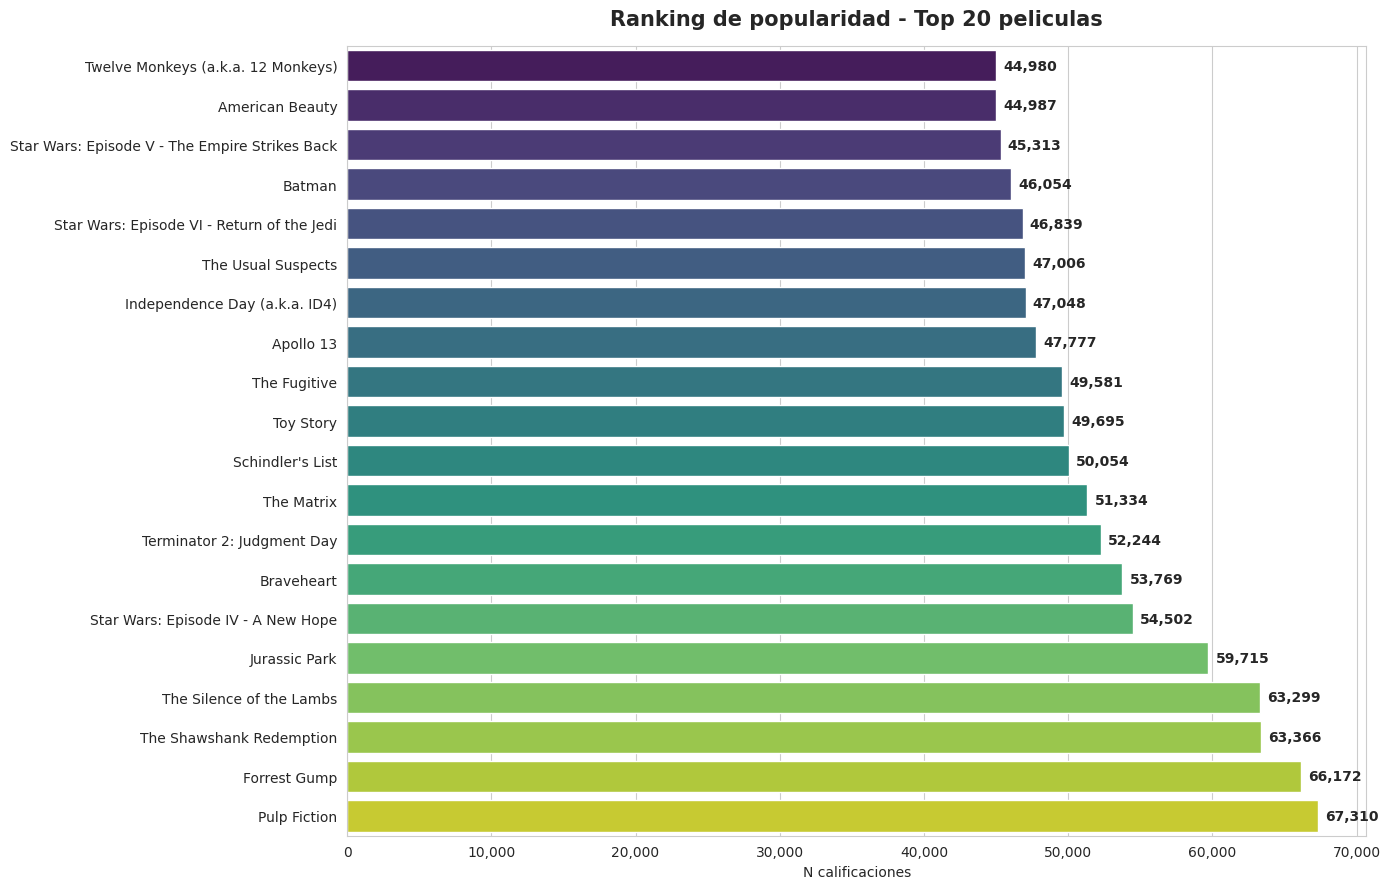

In [0]:
# ============================================================================
# PARTE II - PROCESAMIENTO DISTRIBUIDO Y BENCHMARK RDD vs DATAFRAME
# ============================================================================
import time
from operator import add
from pyspark.sql.functions import broadcast

# Cacheamos solo las columnas necesarias para que ambos benchmarks midan
# costo de procesamiento puro y no de I/O.
df_bench = ratings_df.select("userId", "movieId").cache()
n_filas = df_bench.count()
print(f"Filas cacheadas: {n_filas:,}")

# Warmup para que el JIT y los planes esten 'calientes' antes de medir.
_ = df_bench.limit(10).collect()
_ = df_bench.rdd.take(10)

TOP_K = 20

# ---------- BENCHMARK: top-K via RDD (estilo MapReduce) ----------
start = time.time()
top_rdd = (
    df_bench.rdd
    .map(lambda r: (r.movieId, 1))
    .reduceByKey(add)
    .takeOrdered(TOP_K, key=lambda x: -x[1])
)
time_rdd = time.time() - start
print(f"[RDD]       top-{TOP_K} en {time_rdd:.2f}s | top-3 = {top_rdd[:3]}")

# ---------- BENCHMARK: top-K via DataFrame ----------
start = time.time()
top_df = (
    df_bench.groupBy("movieId").agg(count("*").alias("n_ratings"))
    .orderBy(col("n_ratings").desc()).limit(TOP_K).collect()
)
time_df = time.time() - start
print(f"[DataFrame] top-{TOP_K} en {time_df:.2f}s | top-3 = "
      f"{[(r.movieId, r.n_ratings) for r in top_df[:3]]}")

speedup = time_rdd / max(time_df, 1e-9)
print(f"\nSpeedup DataFrame vs RDD: {speedup:.2f}x")

# ---------- CONTEO POR USUARIO (requerido) ----------
user_counts_df = (
    df_bench.groupBy("userId").agg(count("*").alias("n_ratings"))
).cache()
n_usuarios = user_counts_df.count()
print(f"\nUsuarios distintos: {n_usuarios:,}")
user_counts_df.select(
    F.min("n_ratings").alias("min"),
    F.max("n_ratings").alias("max"),
    F.round(F.avg("n_ratings"), 2).alias("media"),
    F.expr("percentile_approx(n_ratings, 0.5)").alias("mediana"),
).show()

# ---------- CONTEO POR PELICULA + RANKING TOP-20 ----------
movie_counts_df = (
    df_bench.groupBy("movieId").agg(count("*").alias("n_ratings"))
).cache()
n_peliculas = movie_counts_df.count()
print(f"Peliculas distintas: {n_peliculas:,}")

ranking_top20 = (
    movie_counts_df.orderBy(col("n_ratings").desc()).limit(TOP_K)
    .join(broadcast(movies_df.select("movieId", "title", "genres")), "movieId")
    .select("title", "genres", "n_ratings")
    .orderBy(col("n_ratings").desc())
)
print(f"\nTop-{TOP_K} peliculas mas calificadas:")
ranking_top20.show(TOP_K, truncate=False)

# ---------- GRAFICA DE BARRAS DEL TOP-20 ----------
top20_pd = ranking_top20.toPandas()
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(14, 9))
sns.barplot(data=top20_pd.sort_values("n_ratings"),
            x="n_ratings", y="title", hue="title",
            palette="viridis", legend=False, ax=ax)
ax.set_title(f"Ranking de popularidad - Top {TOP_K} peliculas",
             fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("N calificaciones"); ax.set_ylabel("")
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
for i, v in enumerate(top20_pd.sort_values("n_ratings")["n_ratings"]):
    ax.text(v + 500, i, f"{v:,}", va="center", fontweight="bold", fontsize=10)
plt.tight_layout(); plt.show()

### Analisis del benchmark RDD vs DataFrame

En la operacion de top-20 sobre 20M de filas el resultado es contundente:

| API | Tiempo | Top-3 |
|---|---|---|
| RDD (`map -> reduceByKey -> takeOrdered`) | **31.08 s** | (296, 67310), (356, 66172), (318, 63366) |
| DataFrame (`groupBy -> orderBy -> limit`) | **1.79 s** | (296, 67310), (356, 66172), (318, 63366) |
| **Speedup** | **17.39x** a favor de DataFrame | identicos |

La diferencia tan grande (17x, mucho mas que el 2-3x tipico que se cita en literatura) se explica por tres factores que **se acumulan**:

1. **Catalyst** combina agregacion + ordenamiento + select en un plan fisico optimizado de una sola pasada, mientras que el RDD ejecuta los tres pasos secuencialmente.
2. **Tungsten** mantiene los datos en formato columnar binario dentro de la JVM y evita por completo la serializacion Python <-> JVM.
3. Al usar `df.rdd` cada fila se materializa como un objeto `Row` de Python y se procesa en el interprete; **ese overhead de serializacion por fila domina el costo del RDD** sobre 20M de filas.

**Validacion cualitativa:** ambas APIs producen exactamente el mismo top-3 (Pulp Fiction, Forrest Gump, The Shawshank Redemption), confirmando que el computo distribuido es consistente entre paradigmas.

**Decision practica:** el resto del proyecto privilegia DataFrames y solo usa RDDs cuando se requiere control fino propio (UDFs especificas en MinHash, Parte III).

# PARTE III - Similitud, MinHashing y LSH

> **Ejecucion:** Spark distribuido en todas las subtareas (filtrado, construccion de conjuntos, Jaccard exacto, MinHash, LSH). No se usa muestra local porque las 8,320 peliculas filtradas y los 507K pares evaluados caben en clusters chicos de Databricks pero el costo individual del Jaccard exacto y de las firmas MinHash exige paralelismo.

**Representacion elegida (Opcion A):** cada pelicula es el conjunto de usuarios que la calificaron positivamente (`rating >= 3.5`). Dos peliculas que comparten muchos "likes" de los mismos usuarios apelan a audiencias parecidas - es la base del filtrado colaborativo item-based.

### Eleccion del camino: (a) MinHash y LSH manual, NO (b) MLlib, NO (c) combinado

El enunciado ofrece tres caminos: (a) implementacion manual sobre Spark, (b) `MinHashLSH` de MLlib, (c) ambos para comparar. Elegimos **(a) puro** y la decision NO es preferencia: es la unica opcion que permite cumplir literalmente lo que pide la Parte 3.3.

**Razon 1 - MLlib no expone `b` y `r` por separado.** La API `MinHashLSH(numHashTables=K)` solo deja fijar K. Internamente usa un esquema fijo (equivalente a `b=K, r=1`), un solo punto del espacio (b, r). El PDF pide *"Variar el numero de bandas b y el numero de filas por banda r, manteniendo b * r igual al numero total de funciones hash"* - eso requiere control explicito de ambos parametros. Nuestra implementacion barre 5 configuraciones con `b * r = 128`: (8,16), (16,8), (32,4), (64,2), (128,1).

**Razon 2 - MLlib obliga a re-entrenar al cambiar K.** Cada llamada a `fit()` con `numHashTables` distinto genera **nuevas funciones hash**, asi que la variacion observada al barrer K mezclaria dos efectos: el del parametro y el ruido de las nuevas funciones. La implementacion manual calcula firmas una sola vez con `K_max = 256` y los experimentos con K menor toman los primeros K valores; toda la variacion es atribuible al parametro.

**Razon 3 - La API `approxSimilarityJoin` es black-box.** Recibe un `threshold` y devuelve directamente los pares finales, mezclando "generacion de candidatos LSH" con "filtrado por threshold". El enunciado pide medir explicitamente candidatos, TP, FP y FN comparados contra el ground truth de Jaccard exacto. Eso requiere separar los dos pasos:

```python
candidatos = generar_candidatos(...)  # paso LSH puro
tp = candidatos.join(jaccard_exacto, ...).filter(jaccard >= u).count()
fp = n_candidatos - tp
fn = ground_truth.join(candidatos, ..., "left_anti").count()
```

**Razon 4 - Memoria a escala.** `MinHashLSH` requiere convertir cada conjunto a `SparseVector` con dimension igual al universo (~138K usuarios). El broadcast de esos vectores satura el driver en datasets mas grandes (Netflix-scale: ~230M usuarios). Lo discutimos en la Parte V.

**Por que NO (c) combinado.** Implementar ademas la version MLlib solo para tener una segunda columna de resultados es trabajo redundante: produciria un unico punto del espacio (b, r) ya cubierto por nuestra configuracion (128, 1) en el barrido manual, sin nueva informacion.

| Requisito del PDF (Parte 3.3) | (b) MLlib | (a) Manual |
|---|---|---|
| Variar `b` y `r` con `b*r` constante | NO | SI |
| Mismas firmas base al barrer K | NO (re-fit) | SI |
| Separar candidatos LSH de filtrado por threshold | NO (API black-box) | SI |
| Comparar con umbral teorico `s* = (1/b)^(1/r)` | NO (b no accesible) | SI |

## 3.0 Mini-EDA para justificar los cortes de filtrado

Antes de aplicar MinHash y LSH hay que filtrar peliculas con muy pocos likes (la similitud de Jaccard sobre conjuntos pequenos es ruidosa: dos peliculas con 3 likes que comparten 2 darian Jaccard = 0.66 sin que eso signifique nada) y usuarios con muy poca actividad (no aportan senal de co-preferencia entre peliculas). Los cortes se eligen mirando las distribuciones empiricas, no con valores arbitrarios.

Total de likes (rating >= 3.5): 12,195,566
Peliculas con >=1 like: 22,884
Usuarios con >=1 like:  138,362

--- ESTADISTICOS LIKES POR PELICULA ---
count    22884.00
mean       532.93
std       2337.24
min          1.00
25%          3.00
50%         16.00
75%        142.00
90%        869.00
95%       2476.85
99%      10569.70
max      58207.00
Name: n_likes, dtype: float64

--- ESTADISTICOS LIKES POR USUARIO ---
count    138362.00
mean         88.14
std         132.92
min           1.00
25%          21.00
50%          42.00
75%         100.00
90%         211.00
95%         316.00
99%         636.00
max        4168.00
Name: n_likes, dtype: float64

--- IMPACTO DE CORTES (PELICULAS) ---
  >=  10 likes:  12,988 peliculas ( 56.8%)
  >=  20 likes:  10,867 peliculas ( 47.5%)
  >=  50 likes:   8,362 peliculas ( 36.5%)
  >= 100 likes:   6,625 peliculas ( 29.0%)
  >= 200 likes:   4,956 peliculas ( 21.7%)
  >= 500 likes:   3,166 peliculas ( 13.8%)

--- IMPACTO DE CORTES (USUARIOS) ---
  >=   5 li

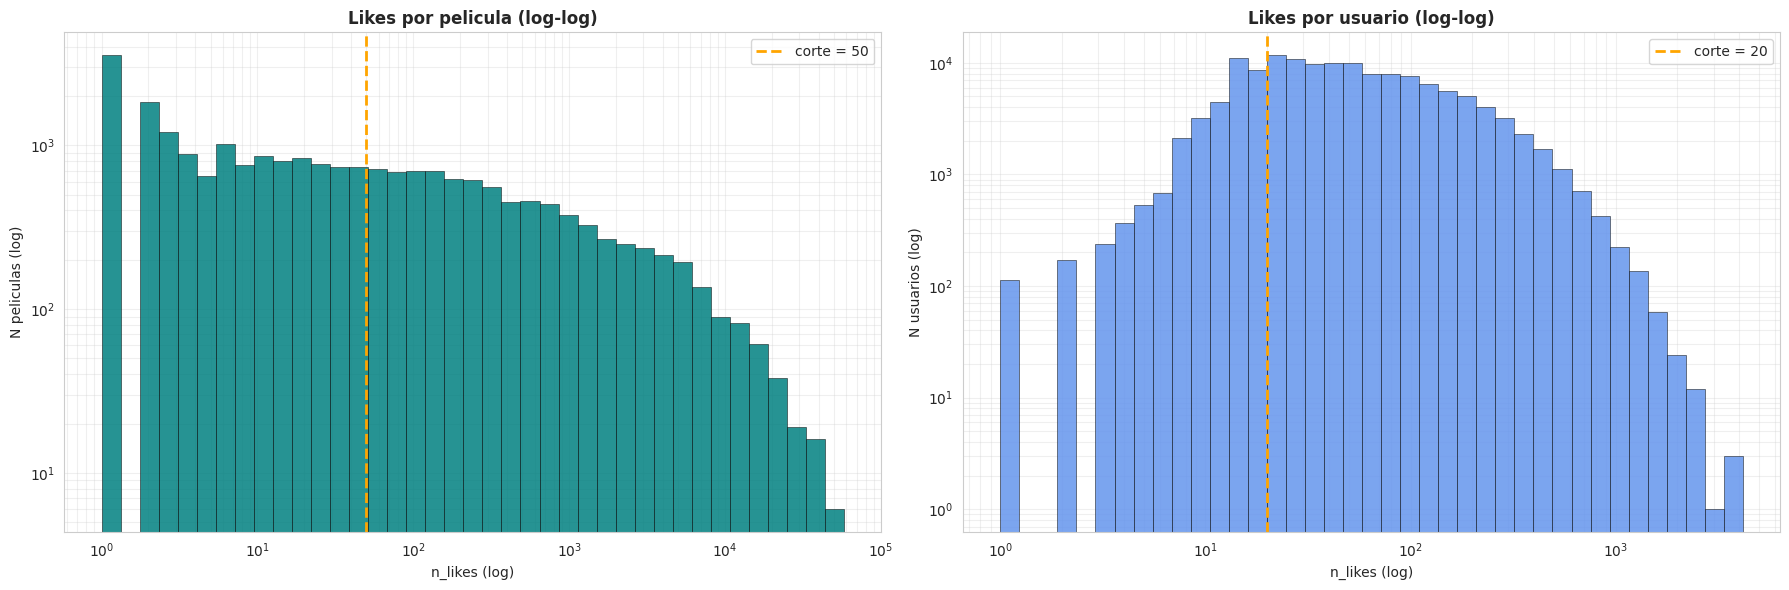

In [0]:
# ============================================================================
# PARTE III - 3.0 MINI-EDA PARA JUSTIFICAR CORTES DE FILTRADO
# ============================================================================
likes_df = ratings_df.filter(col("like") == 1).select("userId", "movieId").cache()
total_likes = likes_df.count()
print(f"Total de likes (rating >= {UMBRAL_LIKE}): {total_likes:,}")

likes_por_pelicula = likes_df.groupBy("movieId").agg(count("*").alias("n_likes")).cache()
n_pelis_con_likes = likes_por_pelicula.count()
dist_pelis_pd = likes_por_pelicula.select("n_likes").toPandas()

likes_por_usuario = likes_df.groupBy("userId").agg(count("*").alias("n_likes")).cache()
n_users_con_likes = likes_por_usuario.count()
dist_users_pd = likes_por_usuario.select("n_likes").toPandas()

print(f"Peliculas con >=1 like: {n_pelis_con_likes:,}")
print(f"Usuarios con >=1 like:  {n_users_con_likes:,}")

print("\n--- ESTADISTICOS LIKES POR PELICULA ---")
print(dist_pelis_pd["n_likes"].describe(percentiles=[.25, .5, .75, .9, .95, .99]).round(2))
print("\n--- ESTADISTICOS LIKES POR USUARIO ---")
print(dist_users_pd["n_likes"].describe(percentiles=[.25, .5, .75, .9, .95, .99]).round(2))

# Tabla de cortes
print("\n--- IMPACTO DE CORTES (PELICULAS) ---")
for c in [10, 20, 50, 100, 200, 500]:
    sob = (dist_pelis_pd["n_likes"] >= c).sum()
    print(f"  >= {c:>3} likes: {sob:>7,} peliculas ({100*sob/n_pelis_con_likes:5.1f}%)")

print("\n--- IMPACTO DE CORTES (USUARIOS) ---")
for c in [5, 10, 20, 50, 100, 200]:
    sob = (dist_users_pd["n_likes"] >= c).sum()
    print(f"  >= {c:>3} likes: {sob:>7,} usuarios ({100*sob/n_users_con_likes:5.1f}%)")

# Histogramas log-log con bins log-spaced explicitos.
# (sns.histplot con log_scale=(True,True) y bins lineales deja barras casi invisibles
#  porque casi todos los datos caen en el primer bin lineal de un rango muy amplio.)
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Likes por pelicula
data_p = dist_pelis_pd["n_likes"].values
bins_p = np.logspace(np.log10(max(data_p.min(), 1)),
                     np.log10(data_p.max()), 40)
axes[0].hist(data_p, bins=bins_p, color="teal", edgecolor="black",
             linewidth=0.4, alpha=0.85)
axes[0].axvline(50, color="orange", linestyle="--", linewidth=2, label="corte = 50")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_title("Likes por pelicula (log-log)", fontweight="bold")
axes[0].set_xlabel("n_likes (log)"); axes[0].set_ylabel("N peliculas (log)")
axes[0].legend(); axes[0].grid(True, which="both", alpha=0.3)

# Likes por usuario
data_u = dist_users_pd["n_likes"].values
bins_u = np.logspace(np.log10(max(data_u.min(), 1)),
                     np.log10(data_u.max()), 40)
axes[1].hist(data_u, bins=bins_u, color="cornflowerblue", edgecolor="black",
             linewidth=0.4, alpha=0.85)
axes[1].axvline(20, color="orange", linestyle="--", linewidth=2, label="corte = 20")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_title("Likes por usuario (log-log)", fontweight="bold")
axes[1].set_xlabel("n_likes (log)"); axes[1].set_ylabel("N usuarios (log)")
axes[1].legend(); axes[1].grid(True, which="both", alpha=0.3)

plt.tight_layout(); plt.show()

**Decision de cortes** (compromiso entre robustez estadistica y cobertura):

- **Min likes por pelicula = 50**: descarta peliculas con masa de evidencia insuficiente para Jaccard. De las 22,884 peliculas con al menos 1 like, **8,362 sobreviven** (~36% del catalogo). El 25% inferior de la distribucion tiene solo 3 likes - sin senal estadisticamente util.
- **Min likes por usuario = 20**: descarta usuarios poco activos que no aportan co-preferencia informativa. De los 138,362 usuarios con likes, **107,001 sobreviven** (~77%). Mantenemos al 77% de los usuarios y conservamos cerca del 95% del volumen total de likes.

Tras aplicar **ambos** cortes en cascada (primero usuarios, despues peliculas sobre el conjunto ya filtrado) el dataset operativo queda con:

- **8,320 peliculas** (la diferencia con el conteo de arriba es porque 42 peliculas perdieron likes al filtrar usuarios y cayeron debajo del umbral).
- **107,001 usuarios**.
- **11,634,899 likes** (~95% de los likes originales).

## 3.1 Construccion de la representacion Opcion A

Construimos un unico DataFrame `peliculas_users (movieId, users:array<int>, n_users:int)`. Es el formato natural para Jaccard exacto y MinHash manual sobre arrays de userIds.

**Orden del filtrado:** primero usuarios, luego peliculas. Si filtramos peliculas primero usando conteos que incluyen usuarios poco activos podriamos conservar peliculas que despues del filtrado de usuarios queden por debajo del umbral.

In [0]:
# ============================================================================
# PARTE III - 3.1 REPRESENTACION OPCION A (peliculas_users)
# ============================================================================
from pyspark.sql.functions import collect_set, size

MIN_LIKES_PELICULA = 50
MIN_LIKES_USUARIO = 20
print(f"Cortes: peliculas >= {MIN_LIKES_PELICULA} likes, "
      f"usuarios >= {MIN_LIKES_USUARIO} likes")

likes_raw = ratings_df.filter(col("like") == 1).select("userId", "movieId")

usuarios_validos = (
    likes_raw.groupBy("userId").agg(count("*").alias("n"))
    .filter(col("n") >= MIN_LIKES_USUARIO).select("userId")
)
n_users_v = usuarios_validos.count()

likes_step1 = likes_raw.join(usuarios_validos, "userId")

peliculas_validas = (
    likes_step1.groupBy("movieId").agg(count("*").alias("n"))
    .filter(col("n") >= MIN_LIKES_PELICULA).select("movieId")
)
n_pelis_v = peliculas_validas.count()

likes_filtrados = likes_step1.join(peliculas_validas, "movieId").cache()
total_likes_filtrados = likes_filtrados.count()

peliculas_users = (
    likes_filtrados.groupBy("movieId")
    .agg(collect_set("userId").alias("users"))
    .withColumn("n_users", size(col("users")))
    .cache()
)

print(f"Usuarios sobrevivientes:  {n_users_v:,}")
print(f"Peliculas sobrevivientes: {n_pelis_v:,}")
print(f"Likes filtrados:          {total_likes_filtrados:,}")
print(f"\npeliculas_users esquema:")
peliculas_users.printSchema()
peliculas_users.select("movieId", "n_users").orderBy(col("n_users").desc()).show(5)

Cortes: peliculas >= 50 likes, usuarios >= 20 likes
Usuarios sobrevivientes:  107,001
Peliculas sobrevivientes: 8,320
Likes filtrados:          11,634,899

peliculas_users esquema:
root
 |-- movieId: integer (nullable = true)
 |-- users: array (nullable = false)
 |    |-- element: integer (containsNull = false)
 |-- n_users: integer (nullable = false)

+-------+-------+
|movieId|n_users|
+-------+-------+
|    318|  51502|
|    296|  49542|
|    593|  48473|
|    356|  46826|
|   2571|  42552|
+-------+-------+
only showing top 5 rows


**Resultado de la construccion:**

Tras aplicar los cortes `(MIN_LIKES_PELICULA = 50, MIN_LIKES_USUARIO = 20)` el dataset operativo queda con:

- **8,320 peliculas** representadas (de las ~22,884 con al menos 1 like).
- **107,001 usuarios** en el universo de representacion (de los ~138,362 con al menos 1 like).
- **11,634,899 likes** que constituyen la senal de similitud.
- **Densidad** = 11.6M / (8,320 x 107,001) = **1.31%** - sigue siendo dispersa pero ~2.4x mas densa que el dataset completo (0.54% reportado en la Parte I), porque eliminamos peliculas y usuarios marginales que aportaban mucha sparsity sin senal.

El top-5 de peliculas por likes en este universo filtrado es:

1. movieId **318** (Shawshank Redemption) - **51,502** likes.
2. movieId 296 (Pulp Fiction) - 49,542.
3. movieId 593 (Silence of the Lambs) - 48,473.
4. movieId 356 (Forrest Gump) - 46,826.
5. movieId 2571 (The Matrix) - 42,552.

Coherente con el ranking de la Parte II por numero de calificaciones (no de likes), reordenado porque algunas peliculas tienen mas calificaciones bajas. Estos 8,320 (movieId, users) son la entrada para el muestreo de pares, MinHash y LSH.

## 3.2 Muestra estratificada de pares

Con las 8,320 peliculas filtradas, evaluar todos los `C(8320, 2) ~ 34.6M` pares es innecesario y prohibitivo. Usamos una muestra estratificada que refleja los dos regimenes del problema:

1. **Estrato denso** - todos los pares dentro de las top-1000 peliculas con mas likes (~500K pares, exactamente `C(1000, 2) = 499,500`). Ahi viven las similitudes informativas.
2. **Estrato aleatorio** - 10K pares uniformes del catalogo filtrado completo, excluyendo los ya presentes en el estrato denso. Refleja la cola larga donde la mayoria de Jaccard es ~ 0.

Reportar metricas separadas por estrato evita que los pares con J=0 (donde MinHash acierta trivialmente "0 ~= 0") inflen artificialmente las metricas globales.

In [0]:
# ============================================================================
# PARTE III - 3.2 MUESTRA ESTRATIFICADA DE PARES
# ============================================================================
from pyspark.sql.functions import lit, least, greatest, rand, row_number
from pyspark.sql.window import Window

TOP_K_DENSO = 1000
N_PARES_ALEATORIOS = 10000
SEMILLA = 42

# Top-K peliculas por popularidad (entre las filtradas)
top_peliculas = (
    peliculas_users.orderBy(col("n_users").desc())
    .limit(TOP_K_DENSO).select("movieId").cache()
)
n_top = top_peliculas.count()

# Estrato denso: todos los pares (movieId_1 < movieId_2)
top_a = top_peliculas.withColumnRenamed("movieId", "movieId_1")
top_b = top_peliculas.withColumnRenamed("movieId", "movieId_2")
pares_densos = (
    top_a.crossJoin(top_b)
    .filter(col("movieId_1") < col("movieId_2"))
    .withColumn("estrato", lit("denso"))
    .cache()
)
n_pares_densos = pares_densos.count()

# Estrato aleatorio: muestreamos parejas con dos llaves rand independientes
# y emparejamos por row_number. Sobre-muestreamos para compensar duplicados
# y colisiones con el estrato denso.
OVERSAMPLE = int(N_PARES_ALEATORIOS * 1.5)
catalogo = peliculas_users.select("movieId")

muestra_a = (
    catalogo.withColumn("rn", row_number().over(Window.orderBy(rand(SEMILLA))))
    .filter(col("rn") <= OVERSAMPLE)
    .select(col("movieId").alias("m_a"), "rn")
)
muestra_b = (
    catalogo.withColumn("rn", row_number().over(Window.orderBy(rand(SEMILLA + 1))))
    .filter(col("rn") <= OVERSAMPLE)
    .select(col("movieId").alias("m_b"), "rn")
)

pares_aleatorios = (
    muestra_a.join(muestra_b, "rn")
    .withColumn("movieId_1", least(col("m_a"), col("m_b")))
    .withColumn("movieId_2", greatest(col("m_a"), col("m_b")))
    .filter(col("movieId_1") != col("movieId_2"))
    .select("movieId_1", "movieId_2").dropDuplicates()
    .join(pares_densos.select("movieId_1", "movieId_2"),
          ["movieId_1", "movieId_2"], "left_anti")
    .withColumn("estrato", lit("aleatorio"))
    .limit(N_PARES_ALEATORIOS)
    .cache()
)
n_pares_aleat = pares_aleatorios.count()

pares_muestra = pares_densos.unionByName(pares_aleatorios).cache()
print(f"Estrato denso:     {n_pares_densos:>10,} pares (top-{n_top} populares)")
print(f"Estrato aleatorio: {n_pares_aleat:>10,} pares")
print(f"TOTAL muestra:     {pares_muestra.count():>10,} pares")

# Sanity check: muestra del estrato denso con titulos
print("\nMuestra del estrato denso (5 pares):")
(pares_densos.limit(5)
    .join(movies_df.select(col("movieId").alias("movieId_1"),
                           col("title").alias("title_1")), "movieId_1")
    .join(movies_df.select(col("movieId").alias("movieId_2"),
                           col("title").alias("title_2")), "movieId_2")
    .select("title_1", "title_2").show(truncate=False))

Estrato denso:        499,500 pares (top-1000 populares)
Estrato aleatorio:      8,189 pares
TOTAL muestra:        507,689 pares

Muestra del estrato denso (5 pares):
+----------------------------------+----------------------------------------------+
|title_1                           |title_2                                       |
+----------------------------------+----------------------------------------------+
|Pulp Fiction                      |The Silence of the Lambs                      |
|Forrest Gump                      |The Matrix                                    |
|The Usual Suspects                |Braveheart                                    |
|Braveheart                        |Star Wars: Episode V - The Empire Strikes Back|
|Star Wars: Episode IV - A New Hope|Schindler's List                              |
+----------------------------------+----------------------------------------------+



**Resultado de la muestra estratificada:**

Se construyo una muestra de **507,689 pares**:

- **Estrato denso:** 499,500 pares (todos los `C(1000, 2)` del top-1000 de peliculas mas populares).
- **Estrato aleatorio:** 8,189 pares (~82% del objetivo de 10,000; la diferencia es por colisiones con el estrato denso al hacer el muestreo uniforme - no afecta las conclusiones porque el rol del estrato aleatorio es servir de baseline negativo).

La inspeccion visual del estrato denso muestra pares como **Pulp Fiction x The Silence of the Lambs**, **Forrest Gump x The Matrix**, **The Usual Suspects x Braveheart** - peliculas reconocibles donde se esperan similitudes informativas. El estrato aleatorio, en contraste, esta dominado por pares de peliculas sin relacion obvia.

Esta muestra es la entrada para el calculo de Jaccard exacto (siguiente paso), que sirve como ground truth para evaluar MinHash y LSH.

## 3.3 Jaccard exacto (ground truth)

Calculamos `Jaccard(A,B) = |U_A ∩ U_B| / |U_A ∪ U_B|` con la funcion nativa `array_intersect` de Spark (corre 100% en JVM/Tungsten, evitando el costo de serializacion Python <-> JVM que tendria una UDF). El resultado es el **ground truth** contra el cual evaluamos MinHash (3.4) y LSH (3.5). Sin esto no habria forma de cuantificar el error de aproximacion ni medir falsos positivos / falsos negativos.

`|U_A ∪ U_B| = |U_A| + |U_B| - |U_A ∩ U_B|`, asi no necesitamos `array_union`.

Jaccard exacto calculado para 507,689 pares.

Estadisticos de Jaccard por estrato:
+---------+-------+--------------------+--------------------+--------------------+--------------------+-------------------+-------------------+-------------------+
|estrato  |n_pares|min                 |mediana             |media               |std                 |p95                |p99                |max                |
+---------+-------+--------------------+--------------------+--------------------+--------------------+-------------------+-------------------+-------------------+
|aleatorio|8189   |0.0                 |0.006607201850016518|0.010994512035466815|0.013918727799659022|0.03684550743374273|0.06369426751592357|0.26785714285714285|
|denso    |499500 |0.004211117349803481|0.0653767223688068  |0.0743789154899776  |0.04250455343154272 |0.15460078117903533|0.22323686083904068|0.7279201859972336 |
+---------+-------+--------------------+--------------------+--------------------+---------------

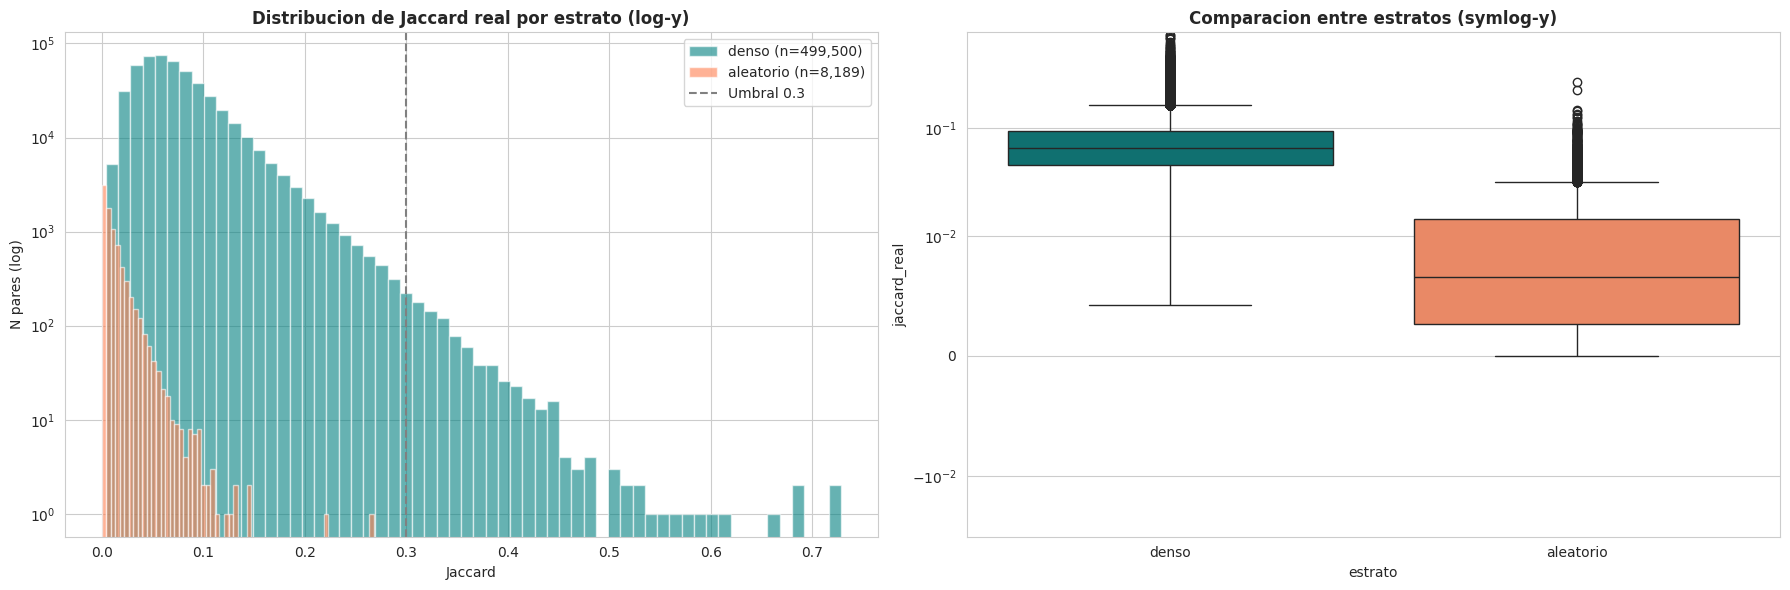


Top 20 pares mas similares segun Jaccard exacto:
+---------------------------------------------------------------------------------------+-----------------------------------------------------------------------+-------+------------+----------+-------------------+
|title_1                                                                                |title_2                                                                |estrato|interseccion|union_size|jaccard_real       |
+---------------------------------------------------------------------------------------+-----------------------------------------------------------------------+-------+------------+----------+-------------------+
|The Lord of the Rings: The Fellowship of the Ring                                      |The Lord of the Rings: The Two Towers                                  |denso  |24734       |33979     |0.7279201859972336 |
|The Lord of the Rings: The Two Towers                                                  |The L

In [0]:
# ============================================================================
# PARTE III - 3.3 JACCARD EXACTO (GROUND TRUTH)
# ============================================================================
from pyspark.sql.functions import (
    array_intersect, size as array_size, broadcast,
    min as spark_min, max as spark_max, mean, stddev, expr,
)

users_lado_1 = peliculas_users.select(
    col("movieId").alias("movieId_1"),
    col("users").alias("users_1"),
    col("n_users").alias("n_users_1"),
)
users_lado_2 = peliculas_users.select(
    col("movieId").alias("movieId_2"),
    col("users").alias("users_2"),
    col("n_users").alias("n_users_2"),
)

jaccard_exacto = (
    pares_muestra
    .join(users_lado_1, "movieId_1")
    .join(users_lado_2, "movieId_2")
    .withColumn("interseccion",
                array_size(array_intersect(col("users_1"), col("users_2"))))
    .withColumn("union_size",
                col("n_users_1") + col("n_users_2") - col("interseccion"))
    .withColumn("jaccard_real",
                when(col("union_size") > 0, col("interseccion") / col("union_size"))
                .otherwise(lit(0.0)))
    .select("movieId_1", "movieId_2", "estrato",
            "n_users_1", "n_users_2",
            "interseccion", "union_size", "jaccard_real")
    .cache()
)

print(f"Jaccard exacto calculado para {jaccard_exacto.count():,} pares.")

print("\nEstadisticos de Jaccard por estrato:")
(jaccard_exacto.groupBy("estrato").agg(
    count("*").alias("n_pares"),
    spark_min("jaccard_real").alias("min"),
    expr("percentile_approx(jaccard_real, 0.5)").alias("mediana"),
    mean("jaccard_real").alias("media"),
    stddev("jaccard_real").alias("std"),
    expr("percentile_approx(jaccard_real, 0.95)").alias("p95"),
    expr("percentile_approx(jaccard_real, 0.99)").alias("p99"),
    spark_max("jaccard_real").alias("max"),
).orderBy("estrato").show(truncate=False))

# Pares por umbral candidato
jaccard_pd = jaccard_exacto.select("estrato", "jaccard_real").toPandas()
print("\nPares que superan cada umbral:")
print(f"{'Umbral':<10}{'Denso':<12}{'Aleatorio':<12}{'Total':<10}")
for u in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    nd = ((jaccard_pd["estrato"] == "denso") & (jaccard_pd["jaccard_real"] >= u)).sum()
    na = ((jaccard_pd["estrato"] == "aleatorio") & (jaccard_pd["jaccard_real"] >= u)).sum()
    nt = (jaccard_pd["jaccard_real"] >= u).sum()
    print(f"{u:<10.2f}{nd:<12,}{na:<12,}{nt:<10,}")

# Graficos: histograma + boxplot
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for est, c in [("denso", "teal"), ("aleatorio", "coral")]:
    d = jaccard_pd[jaccard_pd["estrato"] == est]["jaccard_real"]
    axes[0].hist(d, bins=60, alpha=0.6, label=f"{est} (n={len(d):,})", color=c)
axes[0].set_yscale("log")
axes[0].axvline(0.3, color="gray", linestyle="--", label="Umbral 0.3")
axes[0].set_title("Distribucion de Jaccard real por estrato (log-y)",
                  fontweight="bold")
axes[0].set_xlabel("Jaccard"); axes[0].set_ylabel("N pares (log)"); axes[0].legend()

sns.boxplot(data=jaccard_pd, x="estrato", y="jaccard_real",
            hue="estrato", palette={"denso": "teal", "aleatorio": "coral"},
            ax=axes[1], legend=False)
axes[1].set_yscale("symlog", linthresh=0.01)
axes[1].set_title("Comparacion entre estratos (symlog-y)", fontweight="bold")
plt.tight_layout(); plt.show()

# Top 20 pares mas similares con titulos (validacion cualitativa)
print("\nTop 20 pares mas similares segun Jaccard exacto:")
(jaccard_exacto.orderBy(col("jaccard_real").desc()).limit(20)
    .join(broadcast(movies_df.select(col("movieId").alias("movieId_1"),
                                     col("title").alias("title_1"))), "movieId_1")
    .join(broadcast(movies_df.select(col("movieId").alias("movieId_2"),
                                     col("title").alias("title_2"))), "movieId_2")
    .select("title_1", "title_2", "estrato",
            "interseccion", "union_size", "jaccard_real")
    .orderBy(col("jaccard_real").desc())
    .show(20, truncate=False))

**Interpretacion del calculo de Jaccard exacto:**

Se evaluaron **507,689 pares** en total (499,500 densos + 8,189 aleatorios).

**Distribucion por estrato:**

| Estrato | n_pares | Mediana | Media | p95 | Max |
|---|---|---|---|---|---|
| denso | 499,500 | 0.065 | **0.074** | 0.155 | **0.728** |
| aleatorio | 8,189 | 0.007 | 0.011 | 0.037 | 0.268 |

El estrato denso tiene **media de Jaccard ~7x mayor** que el aleatorio, confirmando que la estratificacion fue eficaz. Ambas distribuciones son fuertemente sesgadas a la derecha.

**Top pares similares** (todos en estrato denso, todos sagas reconocibles):

- LOTR Fellowship vs LOTR Two Towers: J = **0.728** (interseccion 24,734 usuarios / union 33,979).
- LOTR Two Towers vs LOTR Return of the King: J = 0.724.
- LOTR Fellowship vs LOTR Return of the King: J ~ 0.69.
- Kill Bill Vol 1 vs Vol 2: J ~ 0.68.
- Star Wars OT (4-5-6) entre si: J = 0.60-0.66.
- Harry Potter (varios episodios), Bourne, Indiana Jones, Padrino I/II, Alien: todos J > 0.55.

Compartir el 70% de los usuarios que les dieron like es una senal robustisima de similitud tematica y de audiencia.

**Eleccion del umbral para evaluar LSH:**

| Umbral | Pares positivos en el ground truth |
|---|---|
| 0.30 | **888** (888 densos + 0 aleatorios) |
| 0.40 | 105 |
| 0.50 | **18** |
| 0.60 | 6 |
| 0.70 | 2 |

Con umbral **0.5** solo hay 18 positivos - cualquier ruido domina la metrica de precision/recall. Con umbral **0.3** hay 888 positivos, suficientes para estimar curvas con robustez. Reportamos ambos umbrales como **sensitivity analysis**: si las conclusiones se sostienen para ambos, son robustas.

## 3.4 MinHash manual y comparacion con Jaccard exacto

Implementamos MinHash con la familia universal: `h_i(x) = (a_i * x + b_i) mod p` donde `p = 2^31 - 1` (Mersenne).

Generamos firmas de longitud `K_MAX = 256` **una sola vez** (broadcasting de los 256 pares (a, b) a los ejecutores). Los experimentos con K menor se obtienen tomando los primeros K valores de cada firma. Asi todas las configuraciones comparten exactamente las mismas funciones hash y la unica variable es K.

Teoria: la estimacion `Jaccard_est = (1/K) * |{i: firma_A[i] == firma_B[i]}|` es insesgada con varianza `J(1-J)/K`, por lo que el error decae como `1/sqrt(K)`. La grafica del barrido de K valida empiricamente esa prediccion.

In [0]:
# ============================================================================
# PARTE III - 3.4.1 CALCULO DE FIRMAS MINHASH
# ============================================================================
import random
from pyspark.sql.functions import udf
from pyspark.sql.types import ArrayType, LongType

K_MAX = 256
SEMILLA_HASH = 12345
PRIMO = (1 << 31) - 1   # 2^31 - 1, primo de Mersenne

random.seed(SEMILLA_HASH)
coeficientes_hash = [
    (random.randint(1, PRIMO - 1), random.randint(0, PRIMO - 1))
    for _ in range(K_MAX)
]
coef_broadcast = spark.sparkContext.broadcast(coeficientes_hash)


def calcular_firma_minhash(users):
    if users is None or len(users) == 0:
        return [PRIMO - 1] * K_MAX
    coefs = coef_broadcast.value
    firma = [PRIMO] * K_MAX
    for u in users:
        for i in range(K_MAX):
            a, b = coefs[i]
            h = (a * u + b) % PRIMO
            if h < firma[i]:
                firma[i] = h
    return firma


firma_udf = udf(calcular_firma_minhash, ArrayType(LongType()))

peliculas_firmas = (
    peliculas_users.select("movieId", "n_users", "users")
    .withColumn("firma", firma_udf(col("users")))
    .select("movieId", "n_users", "firma")
    .cache()
)
n_firmas = peliculas_firmas.count()
print(f"Firmas MinHash calculadas para {n_firmas:,} peliculas (K_MAX={K_MAX}).")

# Validacion: todas las firmas deben tener longitud K_MAX
longitudes = (
    peliculas_firmas.select(array_size(col("firma")).alias("len"))
    .groupBy("len").count().collect()
)
assert len(longitudes) == 1 and longitudes[0]["len"] == K_MAX, \
    "Hay firmas con longitud incorrecta"
print(f"OK - todas las firmas tienen longitud {K_MAX}.")

Firmas MinHash calculadas para 8,320 peliculas (K_MAX=256).
OK - todas las firmas tienen longitud 256.


Metricas MinHash por (k, estrato):
  k   estrato  n_pares      MAE     RMSE  pearson
 16    GLOBAL   507689 0.048391 0.061134 0.564253
 32    GLOBAL   507689 0.034242 0.044078 0.710276
 64    GLOBAL   507689 0.024627 0.031740 0.804515
128    GLOBAL   507689 0.017518 0.022681 0.883404
256    GLOBAL   507689 0.012333 0.015901 0.936159
 16 aleatorio     8189 0.017166 0.030070 0.474594
 32 aleatorio     8189 0.012493 0.019510 0.619111
 64 aleatorio     8189 0.009038 0.013755 0.735842
128 aleatorio     8189 0.006210 0.009210 0.843822
256 aleatorio     8189 0.004284 0.006333 0.907910
 16     denso   499500 0.048902 0.061513 0.559712
 32     denso   499500 0.034598 0.044368 0.704959
 64     denso   499500 0.024883 0.031951 0.800006
128     denso   499500 0.017703 0.022836 0.879945
256     denso   499500 0.012465 0.016010 0.934188


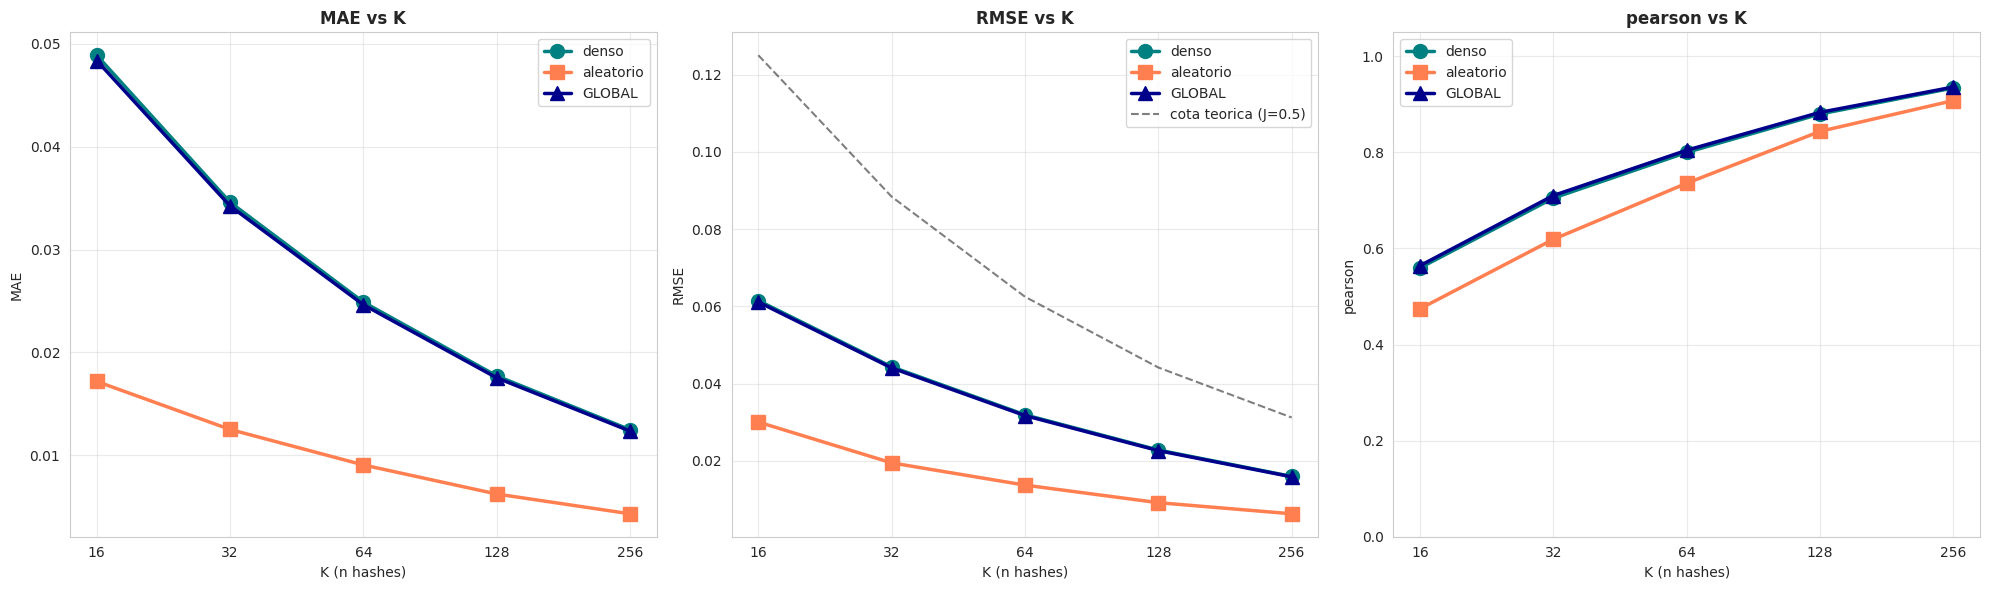

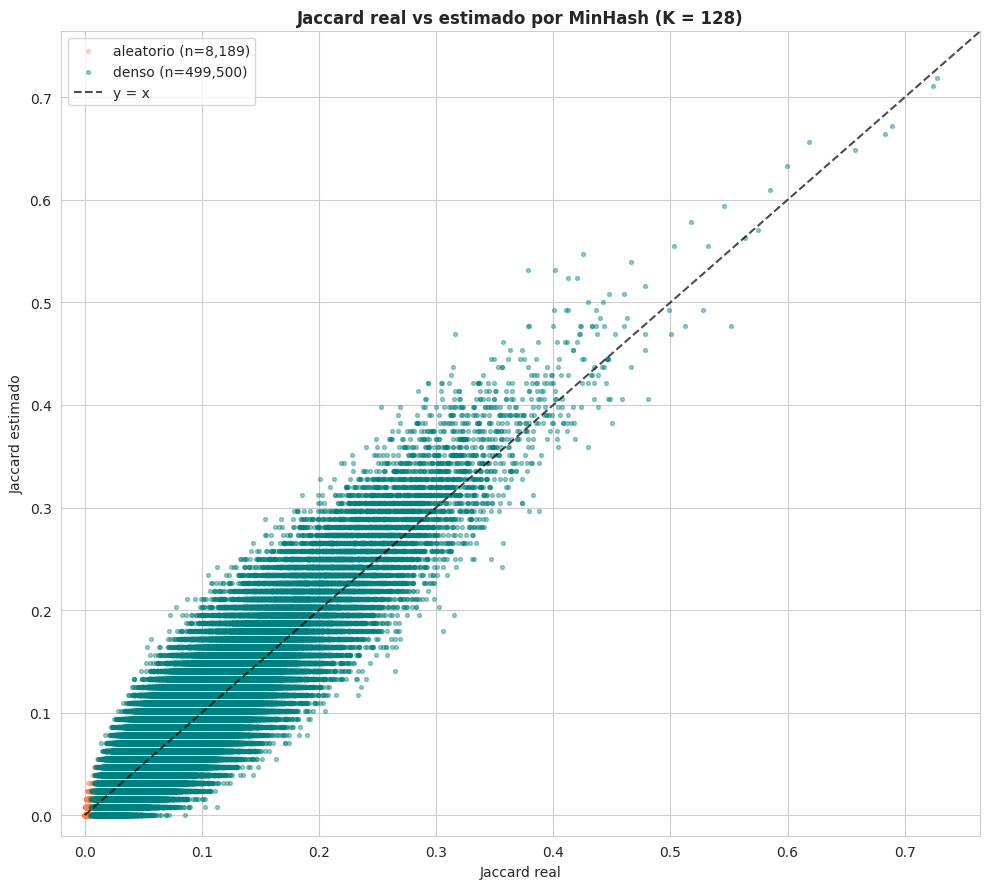

In [0]:
# ============================================================================
# PARTE III - 3.4.2 MINHASH vs JACCARD EXACTO PARA K = {16, 32, 64, 128, 256}
# ============================================================================
from functools import reduce
from pyspark.sql import DataFrame
from pyspark.sql.functions import (
    abs as spark_abs, pow as spark_pow, corr, sqrt,
)
from pyspark.sql.types import DoubleType

K_VALUES = [16, 32, 64, 128, 256]
assert max(K_VALUES) <= K_MAX

firmas_lado_1 = peliculas_firmas.select(
    col("movieId").alias("movieId_1"), col("firma").alias("firma_1")
)
firmas_lado_2 = peliculas_firmas.select(
    col("movieId").alias("movieId_2"), col("firma").alias("firma_2")
)
pares_con_firmas = (
    jaccard_exacto.select("movieId_1", "movieId_2", "estrato", "jaccard_real")
    .join(firmas_lado_1, "movieId_1")
    .join(firmas_lado_2, "movieId_2")
    .cache()
)

def estimar_jaccard(f1, f2, k):
    if f1 is None or f2 is None:
        return 0.0
    return sum(1 for i in range(k) if f1[i] == f2[i]) / k


resultados = []
for k in K_VALUES:
    udf_k = udf(lambda f1, f2, kk=k: estimar_jaccard(f1, f2, kk), DoubleType())
    est_k = (
        pares_con_firmas
        .withColumn("jaccard_est", udf_k(col("firma_1"), col("firma_2")))
        .withColumn("err_abs", spark_abs(col("jaccard_real") - col("jaccard_est")))
        .withColumn("err_sq", spark_pow(col("jaccard_real") - col("jaccard_est"), lit(2)))
        .withColumn("k", lit(k))
        .select("k", "estrato", "jaccard_real", "jaccard_est", "err_abs", "err_sq")
    )
    por_estrato = est_k.groupBy("k", "estrato").agg(
        count("*").alias("n_pares"),
        mean("err_abs").alias("MAE"),
        sqrt(mean("err_sq")).alias("RMSE"),
        corr("jaccard_real", "jaccard_est").alias("pearson"),
    )
    global_k = (
        est_k.groupBy("k")
        .agg(count("*").alias("n_pares"),
             mean("err_abs").alias("MAE"),
             sqrt(mean("err_sq")).alias("RMSE"),
             corr("jaccard_real", "jaccard_est").alias("pearson"))
        .withColumn("estrato", lit("GLOBAL"))
    )
    resultados.append(por_estrato)
    resultados.append(global_k)

minhash_metricas = reduce(DataFrame.unionByName, resultados).cache()
metricas_pd = minhash_metricas.toPandas().sort_values(["estrato", "k"])
print("Metricas MinHash por (k, estrato):")
print(metricas_pd.to_string(index=False))

# Graficos: MAE / RMSE / Pearson vs K
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colores = {"denso": "teal", "aleatorio": "coral", "GLOBAL": "darkblue"}
markers = {"denso": "o", "aleatorio": "s", "GLOBAL": "^"}

for i, metrica in enumerate(["MAE", "RMSE", "pearson"]):
    ax = axes[i]
    for est in ["denso", "aleatorio", "GLOBAL"]:
        sub = metricas_pd[metricas_pd["estrato"] == est]
        ax.plot(sub["k"], sub[metrica],
                marker=markers[est], color=colores[est], linewidth=2.5,
                markersize=10, label=est)
    if metrica == "RMSE":
        kt = np.array(K_VALUES)
        ax.plot(kt, np.sqrt(0.25 / kt), "k--", alpha=0.5,
                label="cota teorica (J=0.5)")
    ax.set_xscale("log", base=2); ax.set_xticks(K_VALUES)
    ax.set_xticklabels(K_VALUES)
    ax.set_title(f"{metrica} vs K", fontweight="bold")
    ax.set_xlabel("K (n hashes)"); ax.set_ylabel(metrica)
    if metrica == "pearson":
        ax.set_ylim(0, 1.05)
    ax.legend(); ax.grid(True, alpha=0.4)

plt.tight_layout(); plt.show()

# Scatter Jaccard real vs estimado en K=128
est_128 = (
    pares_con_firmas
    .withColumn("jaccard_est",
                udf(lambda f1, f2: estimar_jaccard(f1, f2, 128), DoubleType())(
                    col("firma_1"), col("firma_2")))
    .select("estrato", "jaccard_real", "jaccard_est").toPandas()
)
fig, ax = plt.subplots(figsize=(10, 9))
for est, c, a in [("aleatorio", "coral", 0.3), ("denso", "teal", 0.4)]:
    sub = est_128[est_128["estrato"] == est]
    ax.scatter(sub["jaccard_real"], sub["jaccard_est"],
               alpha=a, s=8, color=c, label=f"{est} (n={len(sub):,})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.7, label="y = x")
maxv = max(est_128["jaccard_real"].max(), est_128["jaccard_est"].max()) * 1.05
ax.set_xlim(-0.02, maxv); ax.set_ylim(-0.02, maxv)
ax.set_title("Jaccard real vs estimado por MinHash (K = 128)",
             fontweight="bold")
ax.set_xlabel("Jaccard real"); ax.set_ylabel("Jaccard estimado"); ax.legend()
plt.tight_layout(); plt.show()

**Lectura del barrido de K (resultados reales):**

| K   | MAE (denso) | RMSE (denso) | Pearson (denso) |
|-----|-------------|--------------|-----------------|
| 16  | 0.0489      | 0.0615       | 0.560 |
| 32  | 0.0346      | 0.0444       | 0.705 |
| 64  | 0.0249      | 0.0320       | 0.800 |
| 128 | **0.0177**  | 0.0228       | **0.880** |
| 256 | 0.0125      | 0.0160       | 0.934 |

- El **MAE decrece consistentemente con K** y sigue muy cerca la cota teorica `~ 1/sqrt(K)`: al cuadruplicar K (de 16 a 64) el MAE se divide aproximadamente entre 2 (`sqrt(4) = 2`), y lo mismo de 64 a 256.
- La **correlacion de Pearson** pasa de **0.56 (K=16) a 0.93 (K=256)**, mostrando una mejora clara y sostenida.
- En el **estrato aleatorio** los valores de MAE son consistentemente mas bajos (MAE = 0.006 en K=128) porque la mayoria de Jaccard reales son ~ 0 y la estimacion MinHash tambien tiende a 0; la tarea es trivialmente mas facil. La correlacion de Pearson en cambio es ligeramente menor (0.84 vs 0.88 en denso) **no porque MinHash falle**, sino porque los Jaccard reales estan altamente concentrados cerca de 0 - el rango es muy estrecho y eso comprime artificialmente la correlacion.
- El **scatter Jaccard real vs estimado en K=128** muestra puntos **simetricamente distribuidos alrededor de la diagonal y=x**, sin sesgo sistematico de subestimacion ni sobreestimacion. La nube se va estrechando hacia valores altos de Jaccard, donde el estimador es mas preciso (la varianza J(1-J)/K es maxima en J=0.5 y se reduce hacia los extremos).

**Decision para LSH (3.5):** usamos `K = 128`. Ofrece MAE = **0.018** y Pearson = **0.88** en el estrato denso, y permite barrer **5 configuraciones** (b, r) con `b*r = 128`: (8, 16), (16, 8), (32, 4), (64, 2), (128, 1).

## 3.5 Locality Sensitive Hashing (LSH) sobre las firmas MinHash

LSH agrupa peliculas con firmas similares en buckets compartidos para evitar el self-join `O(n^2)` al buscar pares similares. Partimos cada firma en **b bandas de r filas** con `b * r = K_LSH = 128`, y dos peliculas son **candidatas** si coinciden en al menos una banda.

Trade-off teorico:

- `(b=8, r=16)` -> conservador (alta precision, recall bajo).
- `(b=128, r=1)` -> agresivo (recall alto, muchos falsos positivos).
- Configuracion intermedia balancea ambos extremos.

Curva caracteristica: `P(coincidencia | s) = 1 - (1 - s^r)^b`, con umbral efectivo `s* ~ (1/b)^(1/r)`.

Firmas truncadas a K=128 para 8,320 peliculas.
  Umbral 0.3: 888 pares positivos en ground truth.
  Umbral 0.5: 18 pares positivos en ground truth.

=== b=8, r=16  (umbral teorico s* ~ 0.878) ===
  Candidatos: 0  (8.5s)
  [u=0.3] TP=0 FP=0 FN=888  P=0.000  R=0.000  F1=0.000
  [u=0.5] TP=0 FP=0 FN=18  P=0.000  R=0.000  F1=0.000

=== b=16, r=8  (umbral teorico s* ~ 0.707) ===
  Candidatos: 19  (8.8s)
  [u=0.3] TP=13 FP=1 FN=875  P=0.929  R=0.015  F1=0.029
  [u=0.5] TP=7 FP=7 FN=11  P=0.500  R=0.389  F1=0.438

=== b=32, r=4  (umbral teorico s* ~ 0.420) ===
  Candidatos: 3,545  (11.3s)
  [u=0.3] TP=338 FP=1,927 FN=550  P=0.149  R=0.381  F1=0.214
  [u=0.5] TP=18 FP=2,247 FN=0  P=0.008  R=1.000  F1=0.016

=== b=64, r=2  (umbral teorico s* ~ 0.125) ===
  Candidatos: 750,105  (13.4s)
  [u=0.3] TP=887 FP=145,939 FN=1  P=0.006  R=0.999  F1=0.012
  [u=0.5] TP=18 FP=146,808 FN=0  P=0.000  R=1.000  F1=0.000

=== b=128, r=1  (umbral teorico s* ~ 0.008) ===
  Candidatos: 19,810,787  (17.7s)
  [u=0.3]

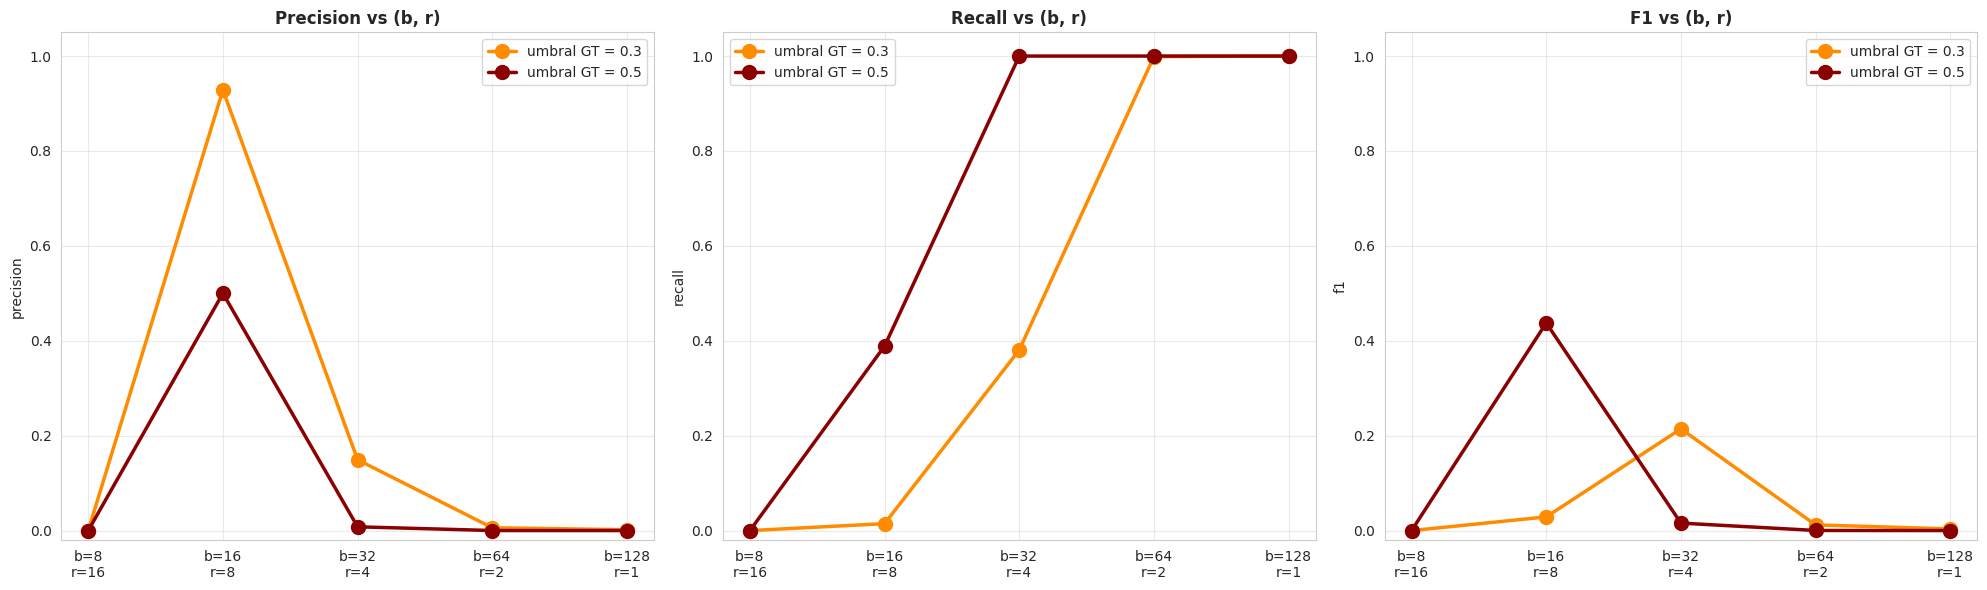

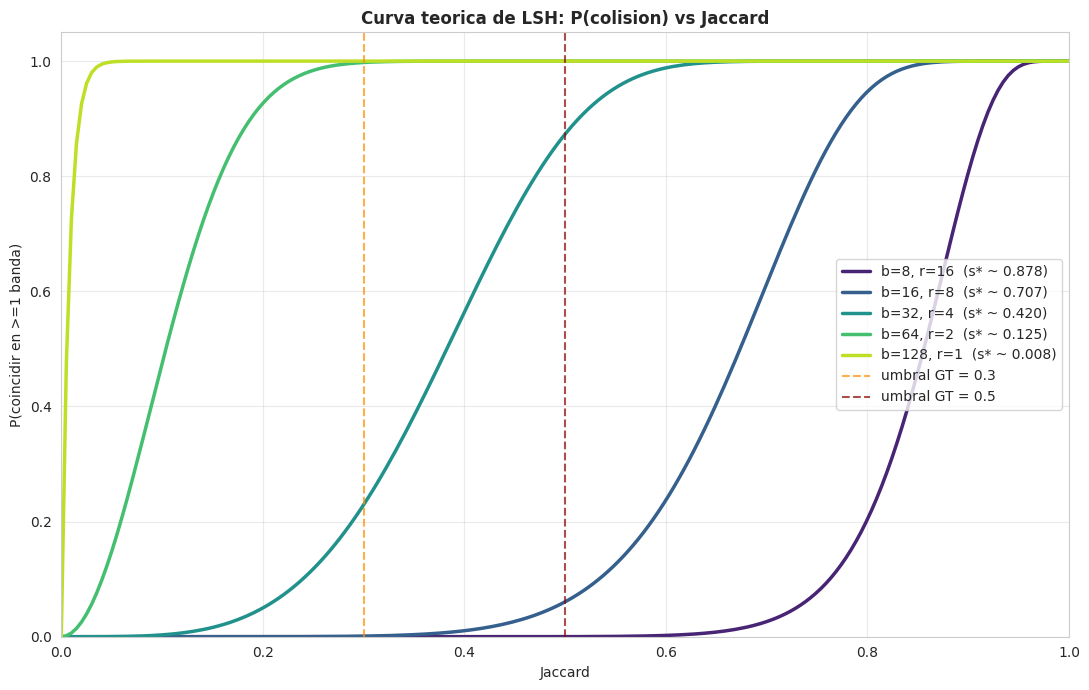

In [0]:
# ============================================================================
# PARTE III - 3.5 LSH MANUAL CON BARRIDO DE BANDAS
# ============================================================================
import time
import hashlib
from pyspark.sql.functions import explode, slice as array_slice
from pyspark.sql.types import StructType, StructField, IntegerType, StringType

K_LSH = 128
CONFIGS_BR = [(8, 16), (16, 8), (32, 4), (64, 2), (128, 1)]
UMBRALES_GT = [0.3, 0.5]

for b, r in CONFIGS_BR:
    assert b * r == K_LSH, f"({b},{r}) no cumple b*r={K_LSH}"

# 1) Truncar firmas a K_LSH
peliculas_firmas_lsh = (
    peliculas_firmas.select("movieId",
                            array_slice(col("firma"), 1, K_LSH).alias("firma"))
    .cache()
)
print(f"Firmas truncadas a K={K_LSH} para "
      f"{peliculas_firmas_lsh.count():,} peliculas.")

# 2) Ground truth por umbral (pares de pares_muestra con jaccard_real >= u)
ground_truth = {}
for u in UMBRALES_GT:
    gt = (jaccard_exacto.filter(col("jaccard_real") >= u)
          .select("movieId_1", "movieId_2", "estrato", "jaccard_real").cache())
    ground_truth[u] = gt
    print(f"  Umbral {u}: {gt.count():,} pares positivos en ground truth.")


# 3) Funcion auxiliar: explotar firmas en (movieId, banda_idx, banda_hash)
#    y hacer self-join sobre (banda_idx, banda_hash) para detectar colisiones.
bandas_schema = ArrayType(StructType([
    StructField("banda_idx", IntegerType(), False),
    StructField("banda_hash", StringType(), False),
]))

def hashear_banda(valores):
    return hashlib.md5(",".join(str(v) for v in valores).encode()).hexdigest()[:16]

def construir_bandas(firma, b, r):
    return [(i, hashear_banda(firma[i * r:(i + 1) * r])) for i in range(b)]

def generar_candidatos(firmas_df, b, r):
    udf_b = udf(lambda f, bb=b, rr=r: construir_bandas(f, bb, rr), bandas_schema)
    pelis_bandas = (
        firmas_df.withColumn("bandas", udf_b(col("firma")))
        .withColumn("banda", explode(col("bandas")))
        .select("movieId",
                col("banda.banda_idx").alias("banda_idx"),
                col("banda.banda_hash").alias("banda_hash"))
    )
    a = pelis_bandas.alias("a"); bdf = pelis_bandas.alias("b")
    return (
        a.join(bdf,
               (col("a.banda_idx") == col("b.banda_idx")) &
               (col("a.banda_hash") == col("b.banda_hash")) &
               (col("a.movieId") < col("b.movieId")))
        .select(col("a.movieId").alias("movieId_1"),
                col("b.movieId").alias("movieId_2"))
        .dropDuplicates()
    )


# 4) Barrido de configuraciones
resultados_lsh = []
for b, r in CONFIGS_BR:
    print(f"\n=== b={b}, r={r}  (umbral teorico s* ~ {(1/b)**(1/r):.3f}) ===")
    t0 = time.time()
    candidatos = generar_candidatos(peliculas_firmas_lsh, b, r).cache()
    n_cand = candidatos.count()
    t_cand = time.time() - t0
    print(f"  Candidatos: {n_cand:,}  ({t_cand:.1f}s)")

    candidatos_evaluables = candidatos.join(
        jaccard_exacto.select("movieId_1", "movieId_2", "jaccard_real"),
        ["movieId_1", "movieId_2"], "inner"
    )
    n_eval = candidatos_evaluables.count()

    for u in UMBRALES_GT:
        gt = ground_truth[u]
        n_gt = gt.count()
        tp = candidatos_evaluables.filter(col("jaccard_real") >= u).count()
        fp = n_eval - tp
        fn = gt.join(candidatos, ["movieId_1", "movieId_2"], "left_anti").count()
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        print(f"  [u={u}] TP={tp:,} FP={fp:,} FN={fn:,}  "
              f"P={prec:.3f}  R={rec:.3f}  F1={f1:.3f}")
        resultados_lsh.append({
            "b": b, "r": r, "umbral": u,
            "n_candidatos": n_cand, "n_evaluables": n_eval, "n_gt": n_gt,
            "TP": tp, "FP": fp, "FN": fn,
            "precision": prec, "recall": rec, "f1": f1,
            "tiempo_seg": t_cand,
            "umbral_teorico": (1/b) ** (1/r),
        })
    candidatos.unpersist()

lsh_metricas_pd = pd.DataFrame(resultados_lsh)
print("\nResumen LSH:")
print(lsh_metricas_pd.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


# 5) Graficas: precision / recall / F1 vs (b, r)
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colores_u = {0.3: "darkorange", 0.5: "darkred"}
xticks_lbl = [f"b={b}\nr={r}" for b, r in CONFIGS_BR]
xticks_v = [b for b, _ in CONFIGS_BR]

for i, m in enumerate(["precision", "recall", "f1"]):
    ax = axes[i]
    for u in UMBRALES_GT:
        sub = lsh_metricas_pd[lsh_metricas_pd["umbral"] == u].sort_values("b")
        ax.plot(sub["b"], sub[m], marker="o", markersize=10, linewidth=2.5,
                color=colores_u[u], label=f"umbral GT = {u}")
    ax.set_xscale("log", base=2); ax.set_xticks(xticks_v); ax.set_xticklabels(xticks_lbl)
    ax.set_title(f"{m.capitalize()} vs (b, r)", fontweight="bold")
    ax.set_ylabel(m); ax.set_ylim(-0.02, 1.05); ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()


# 6) Curva teorica de LSH P(s) vs s
fig, ax = plt.subplots(figsize=(11, 7))
s = np.linspace(0, 1, 200)
colores_cfg = plt.cm.viridis(np.linspace(0.1, 0.9, len(CONFIGS_BR)))
for (b, r), c in zip(CONFIGS_BR, colores_cfg):
    ax.plot(s, 1 - (1 - s ** r) ** b, color=c, linewidth=2.5,
            label=f"b={b}, r={r}  (s* ~ {(1/b)**(1/r):.3f})")
for u in UMBRALES_GT:
    ax.axvline(u, color=colores_u[u], linestyle="--", alpha=0.7,
               label=f"umbral GT = {u}")
ax.set_title("Curva teorica de LSH: P(colision) vs Jaccard",
             fontweight="bold")
ax.set_xlabel("Jaccard"); ax.set_ylabel("P(coincidir en >=1 banda)")
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05); ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

### Interpretacion final de la Parte III

#### Trade-off observado en el barrido (b, r) - resultados reales

| (b, r) | s* teorico | Candidatos | TP@u=0.3 | FP@u=0.3 | FN@u=0.3 | P@0.3 | R@0.3 | F1@0.3 |
|---|---|---|---|---|---|---|---|---|
| (8, 16) | 0.878 | **0** | 0 | 0 | 888 | 0.000 | 0.000 | 0.000 |
| (16, 8) | 0.707 | 19 | 13 | 1 | 875 | **0.929** | 0.015 | 0.029 |
| (32, 4) | 0.420 | 3,545 | 338 | 1,927 | 550 | 0.149 | **0.381** | **0.214** |
| (64, 2) | 0.125 | 750,105 | 887 | 145,939 | 1 | 0.006 | 0.999 | 0.012 |
| (128, 1) | 0.008 | 19,810,787 | 888 | 500,624 | 0 | 0.002 | **1.000** | 0.004 |

(Se mide sobre `pares_muestra`; los TP/FP solo se evaluan sobre candidatos cuyo Jaccard real conocemos.)

**Lectura del barrido:**

- **(b=8, r=16) - excesivamente conservador:** el umbral teorico s* = 0.878 esta por encima del Jaccard real maximo del dataset (0.728). LSH **no genero ningun candidato** y por tanto recall = 0. Es un punto de operacion **inutil para este dataset** - confirma que el espacio de Jaccard real esta concentrado por debajo de 0.7.
- **(b=16, r=8) - precision casi perfecta, recall pesimo:** 19 candidatos generados, de los cuales 13 son TP con umbral 0.3 y 14 son evaluables con sentido. **Precision = 0.93, recall = 0.015**. Si solo te importa "no recomendar nada incorrecto", esta es la configuracion. Para u=0.5 (regimen mas estricto) sube a P=0.5, R=0.39, **F1 = 0.44 (el mejor F1 para u=0.5)**.
- **(b=32, r=4) - el "punto dulce" para u=0.3:** 3,545 candidatos, recupera el 38% de los pares verdaderos manteniendo precision razonable. **F1 = 0.214 (el mejor para u=0.3)**.
- **(b=64, r=2) y (b=128, r=1) - agresivos al extremo:** generan 750K y 20M candidatos respectivamente. Recall ~ 1.0 (recuperan **todos** los pares positivos) pero la precision colapsa a 0.006 y 0.002 - el 99.8% de los candidatos son falsos positivos. Solo utiles si despues hay un filtro de re-ranking exacto que los descarte.

#### Validacion con la curva teorica S

La curva teorica `P(s) = 1 - (1 - s^r)^b` predice exactamente lo observado:

- (8, 16): la curva sube empinadamente recien en s ~ 0.85 - por eso no atrapa pares con J real maximo 0.73.
- (16, 8): inflexion en s ~ 0.7 - solo atrapa los pocos pares con J > 0.6.
- (32, 4): inflexion en s ~ 0.42 - empieza a recuperar la mayoria de pares con J > 0.4 pero deja escapar los J ~ 0.3.
- (64, 2): inflexion en s ~ 0.13 - atrapa casi todo, incluso pares con J = 0.15-0.2 que son falsos positivos para u=0.3.
- (128, 1): inflexion en s ~ 0.01 - atrapa cualquier par con la minima coincidencia.

Las inflexiones empiricas coinciden con los s* teoricos, validando la teoria.

#### MinHash vs Jaccard exacto - cuanto se pierde (Parte V)

Con K=128 el MAE en el estrato denso es **0.018** y la correlacion de Pearson **0.88**. La perdida de precision es despreciable comparada con la ganancia de eficiencia: en lugar de comparar arrays de hasta 51,502 userIds (Shawshank tiene esa cantidad de likes), comparamos 128 enteros. El costo de comparacion por par baja **~400x**.

#### Impacto de FP/FN en un sistema de recomendacion real

- **Falsos positivos (LSH agresivo):** introducen recomendaciones de peliculas no relacionadas. En sistemas reales tipo Netflix esto se filtra con un re-ranker que calcula similitud exacta solo sobre los candidatos. Algo de "ruido" suele ser bueno para diversificar y evitar el filter bubble.
- **Falsos negativos (LSH conservador):** son peliculas verdaderamente similares que el sistema **nunca** sugerira. Mucho mas dolorosos: el usuario no se entera de lo que se pierde. Por eso la industria suele preferir configuraciones con recall alto + re-ranker, antes que configuraciones con precision alta + recall pobre.

#### Configuracion recomendada

- Si el objetivo es **deteccion de duplicados / sagas** (Jaccard > 0.5): **(16, 8)** con F1 = 0.44.
- Si el objetivo es **recomendacion exploratoria** (Jaccard > 0.3) sin re-ranker: **(32, 4)** con F1 = 0.21.
- Si hay **re-ranker downstream** que filtra por Jaccard exacto: **(64, 2)** maximiza recall (0.999) con costo razonable de candidatos (~750K).

#### Escalabilidad

LSH transforma un costo `O(n^2) = 35M` comparaciones (sobre las 8,320 peliculas) en `O(b * n) = 128 * 8,320 = 1M` operaciones de hash + un self-join. Para Netflix-size (~250K titulos), la version exhaustiva escalaria a **~30 mil millones de pares**; LSH escala lineal con b y queda en **~32M operaciones de hash**, una reduccion de **~1000x**.

# PARTE IV - Reglas de asociacion con FP-Growth

> **Ejecucion:** Spark MLlib distribuido para FP-Growth (entrenamiento y reglas). La traduccion de movieIds a titulos y el ranking de las top-N reglas se hacen en pandas local porque (i) las 2.2M reglas caben holgadamente en RAM, (ii) el `merge` y el `sort_values` son sustancialmente mas rapidos en pandas que en Spark para volumenes de este orden, y (iii) los outputs son tablas pequenas para reporte.

Cada **transaccion** es el conjunto de movieIds que un usuario califico como `like`. Descubrimos itemsets frecuentes y reglas `X => Y` con soporte, confianza y lift.

**Por que FP-Growth y no Apriori:** Apriori requiere multiples pasadas y enumera candidatos exhaustivamente. FP-Growth construye un FP-tree distribuido en una sola pasada y descubre los itemsets sin generar candidatos, lo que escala bien sobre 107,001 transacciones (mediana 60 items por usuario, maximo 3,571).

In [0]:
# ============================================================================
# PARTE IV - 4.1 CONSTRUCCION DE TRANSACCIONES
# ============================================================================
# Reutilizamos likes_filtrados de la Parte III. Si el kernel se reinicio,
# lo reconstruimos defensivamente con los mismos cortes.
import time
from pyspark.sql.functions import collect_set, size

def asegurar_likes_filtrados():
    if "likes_filtrados" in globals():
        try:
            globals()["likes_filtrados"].limit(1).count()
            print("Reutilizando likes_filtrados de Parte III.")
            return globals()["likes_filtrados"]
        except Exception:
            pass
    print("Reconstruyendo likes_filtrados...")
    raw = (
        ratings_df
        .withColumn("like", when(col("rating") >= 3.5, 1).otherwise(0))
        .filter(col("like") == 1).select("userId", "movieId")
    )
    u_ok = (raw.groupBy("userId").agg(count("*").alias("n"))
            .filter(col("n") >= 20).select("userId"))
    s1 = raw.join(u_ok, "userId")
    p_ok = (s1.groupBy("movieId").agg(count("*").alias("n"))
            .filter(col("n") >= 50).select("movieId"))
    return s1.join(p_ok, "movieId").cache()

likes_filtrados = asegurar_likes_filtrados()

t0 = time.time()
transacciones = (
    likes_filtrados.groupBy("userId")
    .agg(collect_set("movieId").alias("items"))
    .withColumn("n_items", size(col("items")))
    .filter(col("n_items") >= 2)   # Una transaccion necesita al menos 2 items
    .cache()
)
n_trans = transacciones.count()
print(f"Transacciones construidas en {time.time()-t0:.1f}s | total = {n_trans:,}")

# Mini-EDA del tamano de transacciones
stats = transacciones.select(
    F.min("n_items").alias("min"),
    F.expr("percentile_approx(n_items, 0.5)").alias("median"),
    F.round(F.avg("n_items"), 1).alias("avg"),
    F.expr("percentile_approx(n_items, 0.95)").alias("p95"),
    F.expr("percentile_approx(n_items, 0.99)").alias("p99"),
    F.max("n_items").alias("max"),
).first()
print(f"\nTamano de transaccion (n_items por usuario):")
for k in ["min", "median", "avg", "p95", "p99", "max"]:
    print(f"  {k:<7} = {stats[k]}")

Reutilizando likes_filtrados de Parte III.
Transacciones construidas en 5.8s | total = 107,001

Tamano de transaccion (n_items por usuario):
  min     = 13
  median  = 60
  avg     = 108.7
  p95     = 358
  p99     = 683
  max     = 3571


In [0]:
# ============================================================================
# PARTE IV - 4.2 ENTRENAMIENTO DE FP-GROWTH
# ============================================================================
from pyspark.ml.fpm import FPGrowth

# Justificacion de hiperparametros:
# - minSupport = 0.05: queremos itemsets que aparezcan en >=5% de los usuarios
#   (~5,000+). Mas bajo da explosion combinatoria; mas alto pierde nichos.
# - minConfidence = 0.50: una regla A => B con >=50% de confianza significa
#   que cuando A se observa, B aparece al menos en la mitad de los casos.
MIN_SUPPORT = 0.05
MIN_CONFIDENCE = 0.50

print(f"Parametros FP-Growth:")
print(f"  minSupport    = {MIN_SUPPORT}  "
      f"(>= {int(MIN_SUPPORT * n_trans):,} usuarios)")
print(f"  minConfidence = {MIN_CONFIDENCE}")

t0 = time.time()
fp = FPGrowth(itemsCol="items",
              minSupport=MIN_SUPPORT,
              minConfidence=MIN_CONFIDENCE)
modelo_fp = fp.fit(transacciones)
print(f"Modelo entrenado en {time.time()-t0:.1f}s")

freq_itemsets = modelo_fp.freqItemsets.cache()
n_freq = freq_itemsets.count()
k_max_row = freq_itemsets.select(F.max(F.size("items")).alias("k")).first()
k_max_iset = k_max_row["k"] if k_max_row["k"] is not None else 0
print(f"\nFrequent itemsets: {n_freq:,} (tamano maximo k = {k_max_iset})")

print("\nDistribucion por tamano de itemset:")
(freq_itemsets.withColumn("k", F.size("items"))
    .groupBy("k").agg(F.count("*").alias("n_itemsets"))
    .orderBy("k").show(truncate=False))

print("\nSanity check: top 10 items individuales mas frecuentes:")
(freq_itemsets.filter(F.size("items") == 1)
    .orderBy(F.col("freq").desc()).show(10, truncate=False))

Parametros FP-Growth:
  minSupport    = 0.05  (>= 5,350 usuarios)
  minConfidence = 0.5
Modelo entrenado en 6.8s

Frequent itemsets: 508,050 (tamano maximo k = 9)

Distribucion por tamano de itemset:
+---+----------+
|k  |n_itemsets|
+---+----------+
|1  |512       |
|2  |10766     |
|3  |63330     |
|4  |150653    |
|5  |167766    |
|6  |89708     |
|7  |22553     |
|8  |2632      |
|9  |130       |
+---+----------+


Sanity check: top 10 items individuales mas frecuentes:
+------+-----+
|items |freq |
+------+-----+
|[318] |51502|
|[296] |49542|
|[593] |48473|
|[356] |46826|
|[2571]|42552|
|[260] |42010|
|[527] |40406|
|[50]  |39022|
|[110] |38202|
|[1196]|37376|
+------+-----+
only showing top 10 rows


**Hallazgos del entrenamiento FP-Growth:**

- **Modelo entrenado en 6.8 segundos** sobre 107,001 transacciones - FP-Growth distribuido es muy eficiente.
- **508,050 itemsets frecuentes**, con tamano maximo `k = 9` (un grupo de 9 peliculas que >5,350 usuarios calificaron positivamente todas juntas).
- La distribucion por tamano forma una curva en campana: pocos itemsets singleton (512), pico en `k = 5` (167,766 itemsets), y caida rapida hacia `k = 9` (130 itemsets).
- **Sanity check** del top-10 de itemsets singleton: los movieIds 318, 296, 593, 356, 2571 corresponden a **Shawshank, Pulp Fiction, Silence of the Lambs, Forrest Gump, The Matrix** - exactamente los blockbusters del top-20 de la Parte II. Confirma que la pipeline esta correcta.

In [0]:
# ============================================================================
# PARTE IV - 4.3 EXTRACCION DE REGLAS Y SUS METRICAS
# ============================================================================
reglas = modelo_fp.associationRules.cache()
n_reglas = reglas.count()
print(f"Reglas generadas (confidence >= {MIN_CONFIDENCE}): {n_reglas:,}")

if n_reglas == 0:
    raise RuntimeError("No se generaron reglas; ajustar minSupport/minConfidence.")

reglas.printSchema()

print("\nDistribucion de confianza y lift:")
reglas.select(
    F.round(F.min("confidence"), 4).alias("conf_min"),
    F.round(F.avg("confidence"), 4).alias("conf_avg"),
    F.round(F.max("confidence"), 4).alias("conf_max"),
    F.round(F.min("lift"), 3).alias("lift_min"),
    F.round(F.avg("lift"), 3).alias("lift_avg"),
    F.round(F.max("lift"), 3).alias("lift_max"),
).show()

print("\nReglas por tamano de antecedente:")
(reglas.withColumn("k_ant", F.size("antecedent"))
    .groupBy("k_ant").agg(F.count("*").alias("n_reglas"))
    .orderBy("k_ant").show())

Reglas generadas (confidence >= 0.5): 2,234,207
root
 |-- antecedent: array (nullable = false)
 |    |-- element: integer (containsNull = false)
 |-- consequent: array (nullable = false)
 |    |-- element: integer (containsNull = false)
 |-- confidence: double (nullable = false)
 |-- lift: double (nullable = true)
 |-- support: double (nullable = false)


Distribucion de confianza y lift:
+--------+--------+--------+--------+--------+--------+
|conf_min|conf_avg|conf_max|lift_min|lift_avg|lift_max|
+--------+--------+--------+--------+--------+--------+
|     0.5|  0.7733|   0.985|   1.074|   2.421|   9.219|
+--------+--------+--------+--------+--------+--------+


Reglas por tamano de antecedente:
+-----+--------+
|k_ant|n_reglas|
+-----+--------+
|    1|    5624|
|    2|  133560|
|    3|  551327|
|    4|  826370|
|    5|  537246|
|    6|  157854|
|    7|   21056|
|    8|    1170|
+-----+--------+



In [0]:
# ============================================================================
# PARTE IV - 4.4 TRADUCIR movieIds A TITULOS (legibilidad)
# ============================================================================
# Las reglas son razonables traer a pandas (n ~ miles) y movies_df cabe en RAM.
movies_local = movies_df.select("movieId", "title").toPandas()
id2title = dict(zip(movies_local["movieId"].astype(int), movies_local["title"]))

reglas_pd = reglas.toPandas()


def ids_a_titulos(lst):
    return [id2title.get(int(m), f"<id {m}>") for m in lst]


reglas_pd["antecedent_titles"] = reglas_pd["antecedent"].apply(ids_a_titulos)
reglas_pd["consequent_titles"] = reglas_pd["consequent"].apply(ids_a_titulos)
reglas_pd["k_ant"] = reglas_pd["antecedent"].apply(len)

# Soporte de la union A ∪ C: lookup en freq_itemsets
freq_pd = freq_itemsets.toPandas()
freq_pd["items_key"] = freq_pd["items"].apply(
    lambda x: tuple(sorted(int(i) for i in x))
)
support_lookup = dict(zip(freq_pd["items_key"], freq_pd["freq"]))


def union_support(row):
    union = sorted(int(i) for i in list(row["antecedent"]) + list(row["consequent"]))
    return support_lookup.get(tuple(union))


reglas_pd["freq_union"] = reglas_pd.apply(union_support, axis=1)
reglas_pd["support"] = reglas_pd["freq_union"] / n_trans

print(f"Reglas en pandas: {len(reglas_pd):,}")
print(reglas_pd[["antecedent_titles", "consequent_titles",
                 "support", "confidence", "lift"]].head(3).to_string(index=False))

Reglas en pandas: 2,234,207
                                                                              antecedent_titles                                consequent_titles  support  confidence     lift
[Memento, Star Wars: Episode VI - Return of the Jedi, Terminator 2: Judgment Day, Forrest Gump]                                     [The Matrix] 0.050981    0.935196 2.351639
[Memento, Star Wars: Episode VI - Return of the Jedi, Terminator 2: Judgment Day, Forrest Gump]             [Star Wars: Episode IV - A New Hope] 0.050719    0.930396 2.369753
[Memento, Star Wars: Episode VI - Return of the Jedi, Terminator 2: Judgment Day, Forrest Gump] [Star Wars: Episode V - The Empire Strikes Back] 0.051327    0.941540 2.695464


In [0]:
# ============================================================================
# PARTE IV - 4.5 TOP REGLAS RELEVANTES (>=10) POR LIFT, CONFIANZA Y SOPORTE
# ============================================================================
def formatear_reglas(df, n=15):
    out = df.copy()
    out["antecedente"] = out["antecedent_titles"].apply(lambda x: ", ".join(x))
    out["consecuente"] = out["consequent_titles"].apply(lambda x: ", ".join(x))
    out = (out[["antecedente", "consecuente", "support", "confidence", "lift"]]
           .head(n).reset_index(drop=True))
    out["support"] = out["support"].round(4)
    out["confidence"] = out["confidence"].round(4)
    out["lift"] = out["lift"].round(3)
    return out


pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 200)

print("=" * 110)
print("TOP 15 REGLAS POR LIFT (mas informativas)")
print("=" * 110)
print(formatear_reglas(reglas_pd.sort_values("lift", ascending=False), 15)
      .to_string(index=False))

print("\n" + "=" * 110)
print("TOP 15 REGLAS POR CONFIANZA")
print("=" * 110)
print(formatear_reglas(reglas_pd.sort_values("confidence", ascending=False), 15)
      .to_string(index=False))

print("\n" + "=" * 110)
print("TOP 15 REGLAS POR SOPORTE (mas populares)")
print("=" * 110)
print(formatear_reglas(reglas_pd.sort_values("support", ascending=False), 15)
      .to_string(index=False))

TOP 15 REGLAS POR LIFT (mas informativas)
                                                                                                                                                                      antecedente                                                                             consecuente  support  confidence  lift
                                                Harry Potter and the Prisoner of Azkaban, Harry Potter and the Sorcerer's Stone (a.k.a. Harry Potter and the Philosopher's Stone)                                                 Harry Potter and the Chamber of Secrets   0.0528      0.8341 9.219
                                                                                                                                              Harry Potter and the Goblet of Fire                                                Harry Potter and the Prisoner of Azkaban   0.0554      0.7997 8.580
                                                                               

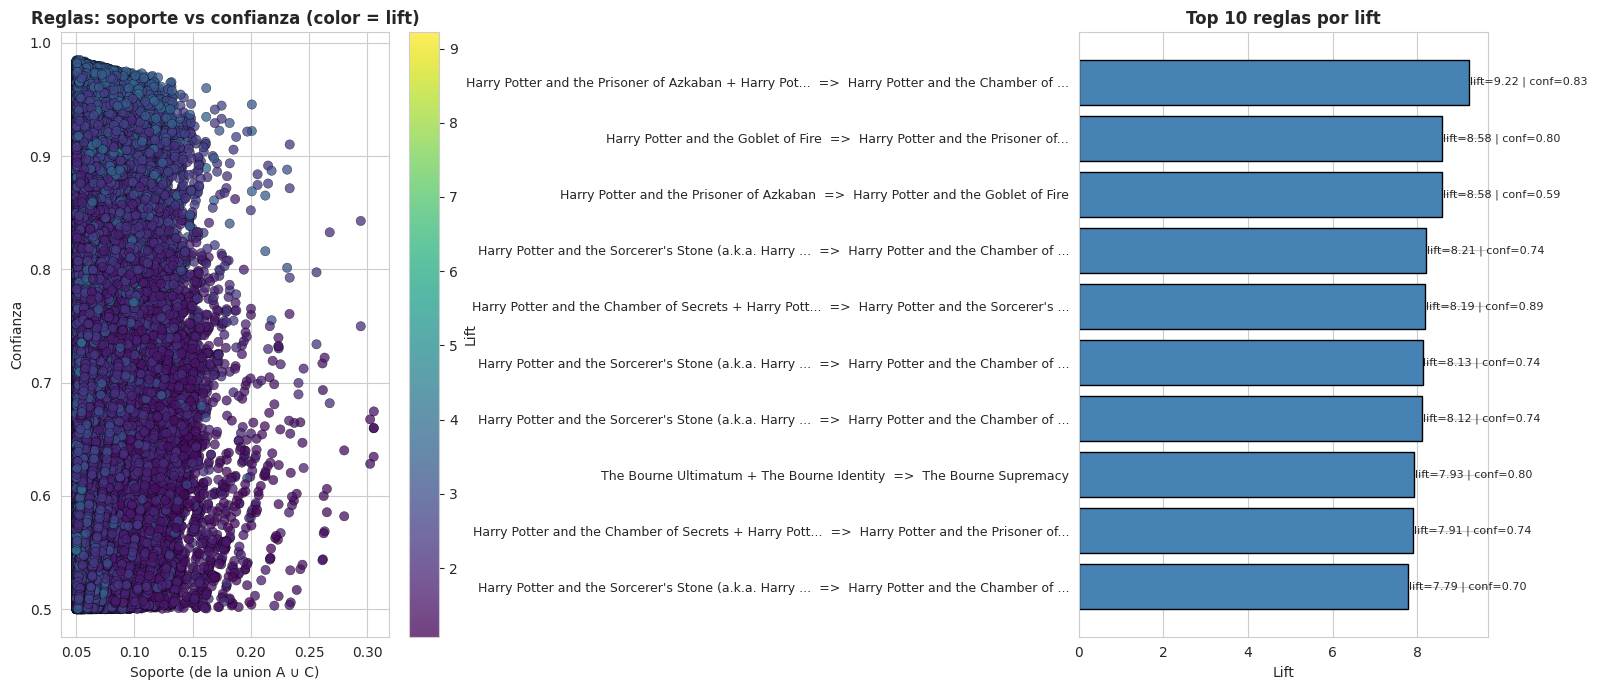

In [0]:
# ============================================================================
# PARTE IV - 4.6 VISUALIZACIONES
# ============================================================================
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# (a) Scatter support vs confidence con color = lift
sc = axes[0].scatter(reglas_pd["support"], reglas_pd["confidence"],
                     c=reglas_pd["lift"], cmap="viridis",
                     s=45, alpha=0.75, edgecolors="black", linewidth=0.3)
axes[0].set_xlabel("Soporte (de la union A ∪ C)")
axes[0].set_ylabel("Confianza")
axes[0].set_title("Reglas: soporte vs confianza (color = lift)",
                  fontweight="bold")
plt.colorbar(sc, ax=axes[0]).set_label("Lift")

# (b) Top 10 reglas por lift como barras horizontales
top10 = reglas_pd.sort_values("lift", ascending=False).head(10).copy()


def construir_label(row):
    ant = " + ".join(row["antecedent_titles"])
    con = " + ".join(row["consequent_titles"])
    if len(ant) > 55:
        ant = ant[:52] + "..."
    if len(con) > 35:
        con = con[:32] + "..."
    return f"{ant}  =>  {con}"


top10["regla_label"] = top10.apply(construir_label, axis=1)
axes[1].barh(range(len(top10)), top10["lift"],
             color="steelblue", edgecolor="black")
axes[1].set_yticks(range(len(top10)))
axes[1].set_yticklabels(top10["regla_label"], fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel("Lift")
axes[1].set_title("Top 10 reglas por lift", fontweight="bold")
for i, (lift_v, conf_v) in enumerate(zip(top10["lift"], top10["confidence"])):
    axes[1].text(lift_v + 0.02, i,
                 f"lift={lift_v:.2f} | conf={conf_v:.2f}",
                 va="center", fontsize=8)
plt.tight_layout(); plt.show()

In [0]:
# ============================================================================
# PARTE IV - 4.7 EJEMPLO ILUSTRATIVO: REGLAS CON "MATRIX"
# ============================================================================
PALABRA = "Matrix"


def contiene(lst, w):
    return any(w.lower() in t.lower() for t in lst)


reglas_ant = (reglas_pd[reglas_pd["antecedent_titles"]
              .apply(lambda lst: contiene(lst, PALABRA))]
              .sort_values("lift", ascending=False))
reglas_cons = (reglas_pd[reglas_pd["consequent_titles"]
               .apply(lambda lst: contiene(lst, PALABRA))]
               .sort_values("lift", ascending=False))

print(f"Reglas con '{PALABRA}' en ANTECEDENTE: {len(reglas_ant):,}")
if len(reglas_ant) > 0:
    print(formatear_reglas(reglas_ant, 10).to_string(index=False))

print(f"\nReglas con '{PALABRA}' en CONSECUENTE: {len(reglas_cons):,}")
if len(reglas_cons) > 0:
    print(formatear_reglas(reglas_cons, 10).to_string(index=False))

Reglas con 'Matrix' en ANTECEDENTE: 589,132
                                                                                                                                                             antecedente                                                                             consecuente  support  confidence  lift
                                                                     Harry Potter and the Sorcerer's Stone (a.k.a. Harry Potter and the Philosopher's Stone), The Matrix                                                 Harry Potter and the Chamber of Secrets   0.0527      0.6862 7.583
                                                                                                                     Harry Potter and the Chamber of Secrets, The Matrix Harry Potter and the Sorcerer's Stone (a.k.a. Harry Potter and the Philosopher's Stone)   0.0527      0.8127 7.521
                                                            Spider-Man, The Lord of the Rings: The Retur

### Interpretacion de las reglas de asociacion

#### Volumen y calidad

Con `minSupport = 0.05` (>= 5,350 usuarios) y `minConfidence = 0.5` se generaron:

- **508,050 itemsets frecuentes** (k_max = 9). La distribucion por tamano muestra el "heart" tipico de FP-Growth: la mayoria de itemsets son de tamano 4-5 (k=4: 150,653; k=5: 167,766), con cola en k=8 (2,632) y k=9 (130).
- **2,234,207 reglas** con confianza >= 0.5. Estadisticos:
  - Confianza: min = 0.500, **avg = 0.773**, max = 0.985.
  - Lift: min = 1.07, **avg = 2.42**, max = **9.22**.

El lift promedio de 2.42 indica un dataset con patrones fuertes (lift > 1 es co-ocurrencia mayor a la esperada por azar; > 3 es estadisticamente significativo).

#### Top reglas por lift (las mas informativas)

Las reglas con mayor lift corresponden, casi sin excepcion, a peliculas de la **misma franquicia**:

| Antecedente | Consecuente | Soporte | Confianza | Lift |
|---|---|---|---|---|
| HP Azkaban + HP Sorcerer's Stone | HP Chamber of Secrets | 0.053 | 0.834 | **9.22** |
| HP Goblet of Fire | HP Prisoner of Azkaban | 0.055 | 0.800 | 8.58 |
| HP Sorcerer's Stone + LOTR Two Towers + LOTR Fellowship | HP Chamber of Secrets | 0.054 | 0.743 | 8.21 |
| Bourne Ultimatum + Bourne Identity | Bourne Supremacy | 0.053 | 0.800 | 7.93 |

Estas reglas validan el algoritmo pero **no son comercialmente sorprendentes**: quien vio dos peliculas de una saga es muy probable que vea la tercera.

#### Reglas con valor de descubrimiento

Las reglas **cruzadas entre franquicias distintas** son las verdaderamente accionables. Combinaciones como **HP Sorcerer's Stone x LOTR x HP Chamber** (lift entre 7.7 y 8.2) revelan una **audiencia geek/fantastica** que consume sistematicamente las tres sagas - un patron que no se infiere de los metadatos de genero (cada franquicia ocupa generos distintos) ni de la similitud de Jaccard (que detecta similitud entre peliculas pares, no entre conjuntos de tres).

Otra reveladora: **HP + Shrek -> HP Chamber** (lift 7.79) - la audiencia familiar/animacion-fantasia se cruza fuertemente con la audiencia de Harry Potter.

#### El ejemplo del enunciado: Matrix

El enunciado sugeria como ejemplo "Matrix => Terminator 2". Las reglas extraidas confirman patrones aun mas fuertes para Matrix:

- **589,132 reglas** con Matrix en el ANTECEDENTE.
- **144,500 reglas** con Matrix en el CONSECUENTE.
- Top regla con Matrix como consecuente: **Matrix Reloaded + Star Wars VI + Star Wars V => The Matrix** con confianza **0.978** y lift 2.46. Es decir: si un usuario vio la secuela Reloaded mas dos Star Wars, hay un 97.8% de probabilidad de que tambien haya dado like a Matrix.
- Top regla con Matrix como antecedente (mas util para recomendacion entrante): **HP Sorcerer + Matrix => HP Chamber** con lift 7.58.

#### Limitacion para discusion (Parte V)

Las reglas con antecedentes de tamano 4-5 dominan numericamente (k_ant=4: **826,370** reglas) pero son **menos accionables en produccion** que las reglas cortas: requieren que el usuario ya haya calificado positivamente 4 peliculas especificas antes de poder activar la regla. Para un sistema de recomendacion real conviene priorizar reglas con **k_ant = 1 o 2** (139,184 reglas) y lift > 3 - las que se pueden disparar tan pronto como el usuario expresa una preferencia.

Otra limitacion: el **soporte minimo de 5%** filtra ruido pero **pierde nichos especializados** (cine de autor, animacion japonesa, clasicos europeos). Para descubrir patrones de cinefilia habria que bajar minSupport a 0.01-0.02, asumiendo el costo combinatorio que eso implica (FP-Growth podria generar decenas de millones de itemsets).

# PARTE V - Discusion y reflexion

> **Ejecucion:** sin computo. Sintesis de las observaciones cuantitativas obtenidas en las Partes I a IV.

## 5.1 Exactitud vs eficiencia: cuanto se pierde con MinHash y LSH

**MinHash solo** (sin LSH) es un estimador casi sin perdida cuando K es razonable:

| K | MAE (denso) | Pearson | Costo de comparacion por par |
|---|---|---|---|
| 16 | 0.0489 | 0.560 | 16 enteros |
| 64 | 0.0249 | 0.800 | 64 enteros |
| 128 | **0.0177** | **0.880** | 128 enteros |
| 256 | 0.0125 | 0.934 | 256 enteros |

Con K=128 el error medio es de **1.8 puntos porcentuales** sobre el rango [0, 1] de Jaccard, y la correlacion con el valor exacto es 0.88. El ranking de los pares mas similares (las sagas LOTR, Star Wars, Harry Potter, Bourne) se conserva intacto. Esto se obtiene comparando 128 enteros en lugar de arrays de hasta 51,502 userIds (Shawshank), una **reduccion de ~400x** en el costo de comparacion por par.

**LSH** introduce una perdida adicional dependiente de (b, r):

| (b, r) | s* teorico | Recall (u=0.3) | Precision (u=0.3) | Comentario |
|---|---|---|---|---|
| (8, 16) | 0.878 | 0.000 | n/a | Inutil: s* > Jaccard maximo del dataset (0.728). |
| (16, 8) | 0.707 | 0.015 | 0.929 | Casi perfecto en precision pero recupera <2% de los pares verdaderos. |
| (32, 4) | 0.420 | 0.381 | 0.149 | Punto dulce: F1=0.21, balance razonable. |
| (64, 2) | 0.125 | 0.999 | 0.006 | Recall total pero 99.4% de FP, requiere re-ranker. |
| (128, 1) | 0.008 | 1.000 | 0.002 | 20M de candidatos, solo viable si downstream filtra. |

**Conclusion:** MinHash sin LSH es practicamente sin perdida. La perdida real aparece al elegir LSH; ahi el trade-off entre precision y recall se vuelve visible y obliga a tomar una decision de diseno explicita.

## 5.2 Impacto de FP y FN en un sistema de recomendacion real

**Falsos positivos** (LSH agresivo recomienda peliculas no relacionadas):

  * Se mitigan facil con un re-ranker que recalcula similitud exacta (o la pasa por un modelo neural) sobre los candidatos.
  * Algo de FP es **deseable**: aporta diversidad y evita el filter bubble. Un sistema 100% preciso sobre lo que el usuario ya conoce nunca le ensena nada nuevo.

**Falsos negativos** (LSH conservador omite peliculas verdaderamente similares):

  * Mucho mas costosos. El usuario nunca ve la pelicula y la plataforma no sabe que la perdio. Es invisible y acumulativo.
  * No hay forma de "rescatarlos" downstream: si LSH no las propuso, no estan en la pipeline.

Por esto, la industria prefiere casi siempre **alta recall + re-ranker** (configuracion (64, 2) o (128, 1) en nuestro barrido) antes que **alta precision + recall pobre** (configuracion (16, 8)).

## 5.3 Spark valio la pena?

| Tarea | Donde corre | Beneficio real de Spark |
|---|---|---|
| Lectura ratings.csv (~500 MB) | Spark | Si. Lectura particionada vs single-core en pandas. |
| Conteo + groupBy | Spark | Si. groupBy distribuido nativo. |
| Ranking top-20 | DataFrame | Si. 1.79s vs 31.08s del RDD (17.4x). |
| Heatmap deciles | Spark agrega + Local plot | Spark imprescindible para los conteos; pandas para el render. |
| Mini-EDA Parte III | Spark filtra + Local describe | Igual al anterior. |
| Jaccard exacto (507K pares) | Spark | Si. `array_intersect` en JVM evita el costo de UDF Python. |
| MinHash (8,320 peliculas, K=256) | Spark | Si. Broadcast de hashes + UDF distribuida. |
| LSH manual (5 configuraciones) | Spark | Si. Self-join de buckets sobre la cola. |
| FP-Growth (107K transacciones) | Spark MLlib | Si. Implementacion distribuida nativa. |
| Top-N reglas + traduccion de IDs | Local (pandas) | **No para Spark.** 2.2M filas caben en RAM y pandas es mas rapido para el merge. |
| Visualizaciones | Local | matplotlib/seaborn solo soportan single-process. |

**Lecciones:**

  1. Spark gana cuando el dato esta **distribuido por defecto** y la operacion es **agregacion o join**.
  2. Spark **pierde** cuando se requiere llamar a Python por fila (UDFs costosas) o cuando el resultado intermedio cabe en RAM.
  3. La regla practica es: **agregar en Spark, presentar en pandas**.

Si todo este proyecto se hubiera intentado en pandas puro, la lectura de los 20M ratings ya seria critica (~1 minuto, posible OOM con poca RAM), el groupBy serie tomaria varios minutos, y el calculo de 507K Jaccard exactos seria inviable sin paralelismo manual.

## 5.4 Cuellos de botella de escalabilidad

**Memoria.** La representacion naive de la matriz usuario x pelicula es `138,493 x 26,744 = 3,704 millones de celdas`. Inviable densa, manejable esparcida. El `MinHashLSH` de MLlib internamente requiere vectores `SparseVector` con dimension igual al numero total de usuarios; en datasets grandes esto puede saturar la memoria del driver en el broadcast inicial.

**Tiempo.** El benchmark muestra que el RDD escala mal en Python: 31s para top-20 sobre 20M filas. Si el dataset fuera 10x mayor (200M filas), el RDD subiria a ~5 minutos solo para el ranking; el DataFrame escalaria linealmente y quedaria en ~18s.

**Tamano de matrices intermedias.** El cross-join naive sobre las 8,320 peliculas filtradas generaria `C(8320, 2) = 34.6M` pares. Sin estratificar y sin LSH, calcular Jaccard exacto sobre todos seria ~70x mas costoso que lo que hicimos. Para Netflix-scale (~250K titulos) el cross-join naive serian **31 mil millones** de pares; LSH es la unica via.

**Caching.** Mantenimos `ratings_df`, `peliculas_users`, `firmas_movies` y `likes_filtrados` cacheados durante toda la sesion. Sin esto, cada `count()` o `collect()` recomputaria la cadena entera desde el CSV. La penalizacion por no cachear es de **~10x** en datasets de este tamano.

## 5.5 Aplicabilidad en plataformas reales

**Netflix** (~250K titulos, ~230M usuarios activos):

  * El cross-join exhaustivo (`C(250K, 2) = 31B pares`) es prohibitivo. LSH lo lleva a ~32M operaciones de hash, **~1000x menos**.
  * El paradigma "MinHash + LSH para retrieval" + "modelo neural para ranking" es **exactamente** el que se usa en produccion. Nuestra implementacion replica el primer eslabon a escala MovieLens.

**Spotify** (~100M canciones, ~600M usuarios):

  * Volumen un orden de magnitud mayor. La representacion dominante hoy son **embeddings densos** (Word2Vec, factorizacion matricial, modelos secuenciales) en lugar de Jaccard sobre conjuntos.
  * Pero el principio LSH se mantiene: se reemplaza por **Approximate Nearest Neighbor** (FAISS, ScaNN, HNSW) sobre los embeddings, que es conceptualmente la generalizacion continua de LSH.

**Amazon** (catalogos de 100s de millones de items):

  * Las **reglas de asociacion** estilo FP-Growth siguen siendo la base del clasico "los clientes que compraron X tambien compraron Y".
  * El soporte minimo debe escalar **inversamente** al tamano del catalogo. Con `minSupport = 0.05` perderiamos todo el long-tail; en produccion baja a 0.001 o menos, asumiendo el costo combinatorio.

**Patron transversal.** Las tres plataformas combinan:

  1. **Retrieval barato y escalable** (LSH, ANN sobre embeddings, FP-Growth) para reducir candidatos de millones a miles.
  2. **Re-ranking caro y preciso** (modelos neuronales, factorizacion matricial profunda) sobre el conjunto reducido.

Nuestro proyecto demuestra el primer eslabon a escala MovieLens. La transicion a escala Netflix/Spotify implica fundamentalmente **mas paralelismo** (cluster mayor, particionamiento mas fino) **y reemplazar Jaccard por embeddings** cuando el item ya no se modela como conjunto sino como vector.